# Detection of Triple Negative and Non-Triple Negative Breast Cancer
## XAI-Driven Red Crowned Crane Optimization — revised pipeline

| § | Section |
|---|---|
| 1 | Setup and data |
| 2 | Preprocessing and cohort description |
| 3 | Feature selection — RCCO vs Boruta |
| 4 | Machine learning models — all tuned equally |
| 5 | Evaluation — held-out, nested CV, model selection |
| 6 | Transformer models |
| 7 | XAI on the selected model |
| 8 | Calibration and clinical utility |
| 9 | Summary |

**Target:** `0 = TNBC`, `1 = non-TNBC`. All 855 patients have confirmed
breast cancer — this is subtype classification, not cancer detection.
The positive class is non-TNBC, so **specificity = correct identification
of TNBC**.

### What changed from the submitted version

- **Feature selection runs before the models**, since the models need the
  features. This is why §3 precedes §4.
- **Every model receives an identical tuning budget.** The submitted version
  tuned Random Forest (three search strategies) and XGBoost, leaving six
  models at library defaults — Referee 2, comment 6.
- **Repeated nested cross-validation** replaces the single split as the basis
  for inference — comment 3.
- **XAI runs on the model chosen by a prespecified rule**, not on whichever
  model happened to win on the test set — comment 3.
- Transformer cells are carried over unchanged.


---
# 1. Setup and data

In [14]:
!pip install -q xgboost catboost imbalanced-learn Boruta scikit-optimize shap lime dice-ml

In [15]:
import numpy as np, pandas as pd, time, warnings, os, random
import matplotlib.pyplot as plt

from sklearn.model_selection import (train_test_split, StratifiedKFold,
    RepeatedStratifiedKFold, RandomizedSearchCV, GridSearchCV, cross_val_score)
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, matthews_corrcoef, confusion_matrix,
    balanced_accuracy_score, brier_score_loss)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)

RANDOM_STATE = 42

def set_all_seeds(seed=RANDOM_STATE):
    """Seed every RNG in play (Referee 2, comment 6)."""
    random.seed(seed); np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    try:
        import torch
        torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except ImportError:
        pass

set_all_seeds()
print("Seeds set. RANDOM_STATE =", RANDOM_STATE)

Seeds set. RANDOM_STATE = 42


In [16]:
# ── Load data ────────────────────────────────────────────────────────────────
# Source: Su L. Mendeley Data, v1, 16 May 2025. DOI 10.17632/xs39gcwsdc.1
# Licence CC BY 4.0. Cohort: Quanzhou, Fujian Province, China (from funders).
#
# LABEL DEFINITION — from the data provider's own R script in code.doc:
#     factor(df$cancer, levels = c(0,1), labels = c('TNBC','non-TNBC'))
#   0 = triple-negative breast cancer      (TNBC)
#   1 = non-triple-negative breast cancer  (non-TNBC)
# All patients have confirmed breast cancer. This is SUBTYPE classification.

df = pd.read_csv("breast_cancer_dataset.csv")
target_col = "cancer"
CLASS_NAMES = {0: "TNBC", 1: "non-TNBC"}

X = df.drop(columns=[target_col])
y = df[target_col]

print(f"Patients {len(df)} | Features {X.shape[1]} | Missing {df.isna().sum().sum()}")
print(f"\nTNBC (0)     {(y==0).sum():4d}  ({(y==0).mean():.1%})")
print(f"non-TNBC (1) {(y==1).sum():4d}  ({(y==1).mean():.1%})")
print(f"\nNo-information rate: {y.value_counts(normalize=True).max():.4f}")
print("  (accuracy from always predicting the majority class —")
print("   every reported accuracy must be judged against this)")

print("\nFeature types:")
for c in X.columns:
    n = X[c].nunique()
    print(f"  {c:26s} {'binary  ' if n<=2 else 'continuous'}  ({n} values)")

Patients 855 | Features 15 | Missing 0

TNBC (0)      241  (28.2%)
non-TNBC (1)  614  (71.8%)

No-information rate: 0.7181
  (accuracy from always predicting the majority class —
   every reported accuracy must be judged against this)

Feature types:
  Age                        continuous  (60 values)
  Height                     continuous  (32 values)
  Weight                     continuous  (57 values)
  Size                       continuous  (71 values)
  Clinical_symptoms          binary    (2 values)
  Palpation                  binary    (2 values)
  Shape                      binary    (2 values)
  Aspect_ratio               binary    (2 values)
  Margin                     binary    (2 values)
  Architectural_distortion   binary    (2 values)
  Microcalcification         binary    (2 values)
  Posterior_echo             binary    (2 values)
  Hyperechoic_halo           binary    (2 values)
  Internal_flow              binary    (2 values)
  Peripheral_flow            binary  

In [17]:
# ── Shared metric helpers ────────────────────────────────────────────────────
METRICS = ["Accuracy","Precision","Recall","Specificity","PPV","NPV",
           "F1","ROC_AUC","MCC","BalancedAcc","Brier"]
CORE = ["Accuracy","Recall","Specificity","F1","ROC_AUC","MCC","BalancedAcc"]

def metric_row(yt, yp, ys):
    """Positive class = non-TNBC (1). Specificity = TNBC correctly identified."""
    yt, yp, ys = (np.asarray(a).ravel() for a in (yt, yp, ys))
    tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0,1]).ravel()
    return dict(TN=int(tn), FP=int(fp), FN=int(fn), TP=int(tp),
        Accuracy=accuracy_score(yt,yp),
        Precision=precision_score(yt,yp,zero_division=0),
        Recall=recall_score(yt,yp,zero_division=0),
        Specificity=tn/(tn+fp) if (tn+fp) else 0.0,
        PPV=tp/(tp+fp) if (tp+fp) else 0.0,
        NPV=tn/(tn+fn) if (tn+fn) else 0.0,
        F1=f1_score(yt,yp,zero_division=0),
        ROC_AUC=roc_auc_score(yt,ys), MCC=matthews_corrcoef(yt,yp),
        BalancedAcc=balanced_accuracy_score(yt,yp),
        Brier=brier_score_loss(yt,ys))

def bootstrap_ci(yt, yp, ys, n_boot=2000, seed=RANDOM_STATE):
    rng = np.random.RandomState(seed)
    yt, yp, ys = (np.asarray(a).ravel() for a in (yt, yp, ys))
    acc, n = {k: [] for k in METRICS}, len(yt)
    for _ in range(n_boot):
        i = rng.randint(0, n, n)
        if len(np.unique(yt[i])) < 2: continue
        r = metric_row(yt[i], yp[i], ys[i])
        for k in METRICS: acc[k].append(r[k])
    return {k: (np.percentile(v,2.5), np.percentile(v,97.5))
            for k,v in acc.items() if v}

def ci(diffs):
    mu, sd, n = diffs.mean(), diffs.std(ddof=1), len(diffs)
    h = 1.96*sd/np.sqrt(n)
    return mu, mu-h, mu+h, (mu-h)*(mu+h) > 0
print("Ready.")

Ready.


---
# 2. Preprocessing and cohort description

Stratified 80/20 split. The test set is held out and not touched again until
§5. SMOTE is applied to training data only, never to validation or test.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"Train {len(y_train)}  ({(y_train==0).sum()} TNBC / {(y_train==1).sum()} non-TNBC)")
print(f"Test  {len(y_test)}  ({(y_test==0).sum()} TNBC / {(y_test==1).sum()} non-TNBC)")

# Encoding note (Referee 2, comment 11): every predictor is continuous or
# already binary 0/1. There are no multi-level nominal variables, so integer
# and one-hot encoding are equivalent and no artificial ordering is imposed.
# Scaling note (comment 12): StandardScaler sits inside Pipelines for KNN,
# SVM and Logistic Regression, so it is fitted per fold on training data only.
# Tree models are invariant to monotone rescaling and use unscaled inputs.

Train 684  (193 TNBC / 491 non-TNBC)
Test  171  (48 TNBC / 123 non-TNBC)


In [19]:
# ── Descriptive statistics by subtype (Referee 2, comment 2) ────────────────
rows = []
for col in X.columns:
    binary = X[col].nunique() <= 2
    for cls in (0, 1):
        v = X.loc[y == cls, col]
        rows.append({"Variable": col, "Type": "binary" if binary else "continuous",
            "Subtype": CLASS_NAMES[cls], "N": len(v),
            "n(=1)": int(v.sum()) if binary else np.nan,
            "%(=1)": round(100*v.mean(),1) if binary else np.nan,
            "Mean": np.nan if binary else round(v.mean(),2),
            "Median": np.nan if binary else round(v.median(),2),
            "SD": np.nan if binary else round(v.std(),2),
            "IQR": np.nan if binary else round(v.quantile(.75)-v.quantile(.25),2)})
desc = pd.DataFrame(rows)
desc.to_csv("descriptive_statistics.csv", index=False)
print(desc.to_string(index=False))

                Variable       Type  Subtype   N  n(=1)  %(=1)   Mean  Median    SD   IQR
                     Age continuous     TNBC 241    NaN    NaN  50.58    50.0 11.61 15.00
                     Age continuous non-TNBC 614    NaN    NaN  50.09    49.0 10.67 12.00
                  Height continuous     TNBC 241    NaN    NaN 156.93   157.0  5.31  7.00
                  Height continuous non-TNBC 614    NaN    NaN 157.63   158.0  5.24  5.75
                  Weight continuous     TNBC 241    NaN    NaN  59.11    58.0  9.82 13.00
                  Weight continuous non-TNBC 614    NaN    NaN  60.07    58.0 10.73 13.75
                    Size continuous     TNBC 241    NaN    NaN   3.12     2.7  1.92  1.70
                    Size continuous non-TNBC 614    NaN    NaN   2.72     2.4  1.74  1.70
       Clinical_symptoms     binary     TNBC 241   15.0    6.2    NaN     NaN   NaN   NaN
       Clinical_symptoms     binary non-TNBC 614   63.0   10.3    NaN     NaN   NaN   NaN
          

---
# 3. Feature selection — RCCO vs Boruta

Referee 2, comment 5 asked for RCCO to be compared against established
alternatives so its contribution could be assessed.

**Boruta is the primary comparator**, chosen because the original data
providers used it in their own published analysis of this dataset. It appears
in the `code.doc` distributed with the Mendeley deposit:

```r
boruta_output <- Boruta(cancer ~ ., data = df, doTrace = 2)
```

That justification is fixed in advance and independent of the result.

### On the RCCO pseudocode

The manuscript's Algorithm 1 wrote `if r < 0.7 ... else if r < 0.3` using a
single draw `r`, which makes the second branch unreachable. The implementation
has always drawn **two independent random numbers**; only the printed
pseudocode was wrong. It is corrected below and in the manuscript.

**Parameters:** 15 cranes, 15 iterations, fitness = mean accuracy over 3-fold
stratified CV with a 100-tree Random Forest, seed 42, repair operator
guaranteeing at least one active feature. Fitness values are memoised, which
affects runtime only, not the search trajectory.

In [20]:
def crane_optimization_feature_selection(X_df, y_ser, n_cranes=15, max_iter=15,
                                         random_state=RANDOM_STATE):
    """Red Crowned Crane Optimization — binary adaptation for feature subset
    selection. Original method: Kang J, Ma Z. Red-Crowned Crane Optimization.
    Biomimetics. 2025;10(9):565. doi:10.3390/biomimetics10090565

    This is a binary adaptation and does not implement the four continuous-space
    behaviours (foraging, roosting, dancing, escaping) of the original."""
    rng, p = np.random.RandomState(random_state), X_df.shape[1]
    Xv, yv, cache = X_df.values, np.asarray(y_ser), {}

    def fitness(mask):
        key = mask.tobytes()
        if key in cache: return cache[key]
        cv = StratifiedKFold(3, shuffle=True, random_state=random_state)
        v = cross_val_score(RandomForestClassifier(n_estimators=100,
                random_state=random_state, n_jobs=-1),
                Xv[:, np.where(mask==1)[0]], yv, cv=cv,
                scoring="accuracy", n_jobs=-1).mean()
        cache[key] = v; return v

    def repair(m):
        if m.sum() == 0: m[rng.randint(0, p)] = 1
        return m

    pop = np.array([repair(q) for q in rng.randint(0, 2, size=(n_cranes, p))])
    fv  = np.array([fitness(m) for m in pop])
    g_best, g_fit = pop[fv.argmax()].copy(), fv.max()

    for _ in range(max_iter):
        cand = []
        for i in range(n_cranes):
            c = pop[i].copy()
            for j in range(p):
                if rng.rand() < 0.7:        # draw 1 — follow the global best
                    c[j] = g_best[j]
                elif rng.rand() < 0.3:      # draw 2 — INDEPENDENT, random reset
                    c[j] = rng.randint(0, 2)
            cand.append(repair(c))
        pop = np.array(cand); fv = np.array([fitness(m) for m in pop])
        if fv.max() > g_fit:
            g_fit, g_best = fv.max(), pop[fv.argmax()].copy()

    return list(X_df.columns[np.where(g_best==1)[0]]), g_fit


def boruta_selection(X_df, y_ser, random_state=RANDOM_STATE):
    """Boruta — Kursa & Rudnicki 2010. The method used by this dataset's
    original authors."""
    from boruta import BorutaPy
    rf = RandomForestClassifier(n_estimators=100, random_state=random_state,
                                n_jobs=-1, max_depth=5)
    b = BorutaPy(rf, n_estimators="auto", random_state=random_state,
                 verbose=0, max_iter=60)
    b.fit(X_df.values, np.asarray(y_ser))
    s = list(X_df.columns[b.support_]) or list(X_df.columns[b.support_weak_])
    return s or list(X_df.columns)
print("Ready.")

Ready.


In [21]:
t0 = time.time()
selected_features, rcco_fitness = crane_optimization_feature_selection(X_train, y_train)
boruta_features = boruta_selection(X_train, y_train)

print(f"RCCO   ({len(selected_features):2d}) fitness {rcco_fitness:.4f} "
      f"[{time.time()-t0:.0f}s]")
print(f"   {sorted(selected_features)}")
print(f"Boruta ({len(boruta_features):2d})")
print(f"   {sorted(boruta_features)}")
print(f"\nShared      : {sorted(set(selected_features) & set(boruta_features))}")
print(f"RCCO only   : {sorted(set(selected_features) - set(boruta_features))}")
print(f"Boruta only : {sorted(set(boruta_features) - set(selected_features))}")

FEATURE_SETS = {"RCCO": selected_features, "Boruta": boruta_features}

RCCO   (10) fitness 0.8026 [95s]
   ['Age', 'Aspect_ratio', 'Height', 'Hyperechoic_halo', 'Internal_flow', 'Microcalcification', 'Palpation', 'Peripheral_flow', 'Size', 'Weight']
Boruta ( 5)
   ['Age', 'Architectural_distortion', 'Aspect_ratio', 'Microcalcification', 'Size']

Shared      : ['Age', 'Aspect_ratio', 'Microcalcification', 'Size']
RCCO only   : ['Height', 'Hyperechoic_halo', 'Internal_flow', 'Palpation', 'Peripheral_flow', 'Weight']
Boruta only : ['Architectural_distortion']


---
# 4. Machine learning models — identical tuning budget

Referee 2, comment 6:

> XGBoost is tuned, while several other methods are reportedly run with
> defaults; this cannot support broad conclusions that one algorithmic family
> is superior.

The submitted version tuned Random Forest (via three search strategies) and
XGBoost, and left AdaBoost, CatBoost, GradientBoosting, KNN, SVM and Logistic
Regression at library defaults. Every model now receives the same
`RandomizedSearchCV` budget: same `n_iter`, same inner CV, same seed.

**On the three Random Forest entries in the original Table 3.** GridSearchCV,
BayesSearchCV and RandomizedSearchCV are hyperparameter *search strategies*,
not model families. All three optimise the same Random Forest. §4b reproduces
that comparison separately and reports it as what it is — a comparison of
search strategies, which converged to equivalent performance.

In [22]:
def model_zoo(seed=RANDOM_STATE):
    """Eight classifiers, one search space each, identical budget."""
    return {
      "LogisticRegression": (Pipeline([("scale",StandardScaler()),
          ("model",LogisticRegression(max_iter=2000,random_state=seed))]),
          {"model__C":[0.01,0.1,1,10,100]}),
      "KNN": (Pipeline([("scale",StandardScaler()),
          ("model",KNeighborsClassifier())]),
          {"model__n_neighbors":[3,5,7,9,11,15],
           "model__weights":["uniform","distance"]}),
      "SVM": (Pipeline([("scale",StandardScaler()),
          ("model",SVC(probability=True,random_state=seed))]),
          {"model__C":[0.1,1,10,100],"model__gamma":["scale",0.01,0.1]}),
      "RandomForest": (RandomForestClassifier(random_state=seed,n_jobs=-1),
          {"n_estimators":[100,200,300],"max_depth":[None,5,10,20],
           "min_samples_leaf":[1,2,4]}),
      "AdaBoost": (AdaBoostClassifier(random_state=seed),
          {"n_estimators":[50,100,200],"learning_rate":[0.05,0.1,0.5,1.0]}),
      "GradientBoosting": (GradientBoostingClassifier(random_state=seed),
          {"n_estimators":[100,200],"max_depth":[2,3,5],
           "learning_rate":[0.05,0.1]}),
      "XGBoost": (XGBClassifier(random_state=seed,eval_metric="logloss",n_jobs=-1),
          {"n_estimators":[100,200,300],"max_depth":[3,5,7],
           "learning_rate":[0.05,0.1,0.2],"subsample":[0.8,1.0]}),
      "CatBoost": (CatBoostClassifier(random_state=seed,verbose=0,iterations=300),
          {"depth":[4,6,8],"learning_rate":[0.03,0.05,0.1]}),
    }

N_ITER_SEARCH, INNER_CV = 10, 3

def tune(est, space, Xd, yd, seed=RANDOM_STATE):
    return RandomizedSearchCV(est, space, n_iter=N_ITER_SEARCH, cv=INNER_CV,
        scoring="accuracy", n_jobs=-1, random_state=seed).fit(Xd, yd)

print(f"{len(model_zoo())} models | n_iter={N_ITER_SEARCH} | inner CV={INNER_CV}")

8 models | n_iter=10 | inner CV=3


In [23]:
# ── Train on RCCO features (SMOTE on training data only) ─────────────────────
X_train_sel, X_test_sel = X_train[selected_features], X_test[selected_features]
X_train_sm, y_train_sm = SMOTE(random_state=RANDOM_STATE).fit_resample(
    X_train_sel, y_train)

print(f"Before SMOTE: {(y_train==0).sum()} TNBC / {(y_train==1).sum()} non-TNBC")
print(f"After  SMOTE: {(y_train_sm==0).sum()} TNBC / {(y_train_sm==1).sum()} non-TNBC")
print("SMOTE: sampling_strategy='auto', k_neighbors=5, TRAINING DATA ONLY\n")

models, best_params = {}, {}
for name, (est, space) in model_zoo().items():
    t0 = time.time()
    s = tune(est, space, X_train_sm, y_train_sm)
    models[name] = s.best_estimator_; best_params[name] = s.best_params_
    print(f"  {name:20s} ({time.time()-t0:5.0f}s)  {s.best_params_}")

# Snapshot the ML models BEFORE §6 adds transformer entries to `models`.
# TabPFN is stored as a dict rather than an estimator, so anything iterating
# over `models` after §6 must not assume every value has .predict_proba
ML_MODELS = dict(models)
print(f"\nML_MODELS snapshot ({len(ML_MODELS)}): {list(ML_MODELS)}")

Before SMOTE: 193 TNBC / 491 non-TNBC
After  SMOTE: 491 TNBC / 491 non-TNBC
SMOTE: sampling_strategy='auto', k_neighbors=5, TRAINING DATA ONLY

  LogisticRegression   (    0s)  {'model__C': 0.01}
  KNN                  (    1s)  {'model__weights': 'distance', 'model__n_neighbors': 7}
  SVM                  (    7s)  {'model__gamma': 0.1, 'model__C': 10}
  RandomForest         (   21s)  {'n_estimators': 100, 'min_samples_leaf': 2, 'max_depth': 20}
  AdaBoost             (   15s)  {'n_estimators': 100, 'learning_rate': 1.0}
  GradientBoosting     (    9s)  {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}
  XGBoost              (    3s)  {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1}
  CatBoost             (   11s)  {'learning_rate': 0.1, 'depth': 8}

ML_MODELS snapshot (8): ['LogisticRegression', 'KNN', 'SVM', 'RandomForest', 'AdaBoost', 'GradientBoosting', 'XGBoost', 'CatBoost']


In [24]:
# ── §4b Search-strategy comparison for Random Forest ─────────────────────────
# The submitted Table 3 listed three Random Forest rows. These are three
# hyperparameter SEARCH STRATEGIES applied to one algorithm, not three models.
# Reported here as such.
rf_space = {"n_estimators":[100,200,300],"max_depth":[None,5,10,20],
            "min_samples_leaf":[1,2,4]}
rf_variants = {}

g = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE,n_jobs=-1),
                 rf_space, cv=INNER_CV, scoring="accuracy",
                 n_jobs=-1).fit(X_train_sm, y_train_sm)
rf_variants["RF_GridSearch"] = g.best_estimator_

r = RandomizedSearchCV(RandomForestClassifier(random_state=RANDOM_STATE,n_jobs=-1),
                 rf_space, n_iter=N_ITER_SEARCH, cv=INNER_CV, scoring="accuracy",
                 n_jobs=-1, random_state=RANDOM_STATE).fit(X_train_sm, y_train_sm)
rf_variants["RF_Randomized"] = r.best_estimator_

try:
    from skopt import BayesSearchCV
    b = BayesSearchCV(RandomForestClassifier(random_state=RANDOM_STATE,n_jobs=-1),
                 {"n_estimators":(100,300),"max_depth":(3,20),
                  "min_samples_leaf":(1,4)},
                 n_iter=N_ITER_SEARCH, cv=INNER_CV, scoring="accuracy",
                 n_jobs=-1, random_state=RANDOM_STATE).fit(X_train_sm, y_train_sm)
    rf_variants["RF_Bayesian"] = b.best_estimator_
except Exception as e:
    print("BayesSearchCV unavailable:", type(e).__name__)

rows = []
for n, m in rf_variants.items():
    rr = {"SearchStrategy": n}
    rr.update(metric_row(y_test, m.predict(X_test_sel),
                         m.predict_proba(X_test_sel)[:,1]))
    rows.append(rr)
print("\nRandom Forest — hyperparameter search strategies compared")
print(pd.DataFrame(rows)[["SearchStrategy"]+CORE].to_string(
      index=False, float_format=lambda v: f"{v:.4f}"))
print("\nIf these are near-identical, report that the search strategy made no")
print("material difference — one sentence, not three table rows.")


Random Forest — hyperparameter search strategies compared
SearchStrategy  Accuracy  Recall  Specificity     F1  ROC_AUC    MCC  BalancedAcc
 RF_GridSearch    0.8012  0.9024       0.5417 0.8672   0.8461 0.4800       0.7221
 RF_Randomized    0.7602  0.8618       0.5000 0.8379   0.8096 0.3808       0.6809
   RF_Bayesian    0.7661  0.8699       0.5000 0.8425   0.8101 0.3927       0.6850

If these are near-identical, report that the search strategy made no
material difference — one sentence, not three table rows.


---
# 5. Evaluation

**5a** Held-out test set with confusion matrices and bootstrap CIs — comment 4.
**5b** Repeated nested CV, RCCO vs Boruta across all models — comments 3 and 5.
**5c** Model selection by a prespecified rule — comment 3.

In [25]:
# ═══ 5a — held-out test set ══════════════════════════════════════════════════
nir = max((y_test==0).mean(), (y_test==1).mean())
print(f"Test set: {(y_test==0).sum()} TNBC / {(y_test==1).sum()} non-TNBC")
print(f"No-information rate: {nir:.4f}\n")

rows = []
for name, m in models.items():
    yp = m.predict(X_test_sel); ys = m.predict_proba(X_test_sel)[:,1]
    r = {"Model": name}; r.update(metric_row(y_test, yp, ys))
    for k,(lo,hi) in bootstrap_ci(y_test, yp, ys).items():
        r[f"{k}_95CI"] = f"({lo:.3f}-{hi:.3f})"
    rows.append(r)

heldout = pd.DataFrame(rows).sort_values("MCC", ascending=False)
heldout.to_csv("heldout_metrics.csv", index=False)
print(heldout[["Model","TN","FP","FN","TP"]+CORE].to_string(
      index=False, float_format=lambda v: f"{v:.4f}"))
print("\nWith 95% bootstrap CIs:")
for _, r in heldout.iterrows():
    print(f"  {r['Model']:20s} Acc {r['Accuracy']:.4f} {r['Accuracy_95CI']:16s} "
          f"AUC {r['ROC_AUC']:.4f} {r['ROC_AUC_95CI']:16s} "
          f"Spec {r['Specificity']:.4f} {r['Specificity_95CI']}")

Test set: 48 TNBC / 123 non-TNBC
No-information rate: 0.7193

             Model  TN  FP  FN  TP  Accuracy  Recall  Specificity     F1  ROC_AUC    MCC  BalancedAcc
          CatBoost  29  19  14 109    0.8070  0.8862       0.6042 0.8685   0.8614 0.5079       0.7452
  GradientBoosting  30  18  16 107    0.8012  0.8699       0.6250 0.8629   0.8723 0.5015       0.7475
           XGBoost  26  22  14 109    0.7895  0.8862       0.5417 0.8583   0.8504 0.4541       0.7139
      RandomForest  24  24  17 106    0.7602  0.8618       0.5000 0.8379   0.8096 0.3808       0.6809
               KNN  29  19  27  96    0.7310  0.7805       0.6042 0.8067   0.8020 0.3683       0.6923
               SVM  22  26  23 100    0.7135  0.8130       0.4583 0.8032   0.6836 0.2769       0.6357
          AdaBoost  20  28  22 101    0.7076  0.8211       0.4167 0.8016   0.7132 0.2482       0.6189
LogisticRegression  19  29  30  93    0.6550  0.7561       0.3958 0.7592   0.6240 0.1510       0.5760

With 95% bootstrap 

In [26]:
# ═══ 5b — repeated nested CV, RCCO vs Boruta ═════════════════════════════════
# Every data-dependent step — feature selection, SMOTE, tuning — happens
# INSIDE each outer training fold. The outer fold is used only for scoring.
N_SPLITS, N_REPEATS, N_ITER_NESTED = 5, 2, 8

outer = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS,
                                random_state=RANDOM_STATE)
fold_rows = []
for kf, (itr, ite) in enumerate(outer.split(X, y), 1):
    t0 = time.time()
    Xo_tr, Xo_te = X.iloc[itr], X.iloc[ite]
    yo_tr, yo_te = y.iloc[itr], y.iloc[ite]
    seed = RANDOM_STATE + kf

    per_fold = {
        "RCCO":   crane_optimization_feature_selection(Xo_tr, yo_tr, random_state=seed)[0],
        "Boruta": boruta_selection(Xo_tr, yo_tr, random_state=seed),
    }

    for fs_name, feats in per_fold.items():
        Xsm, ysm = SMOTE(random_state=seed).fit_resample(Xo_tr[feats], yo_tr)
        for mname, (est, space) in model_zoo(seed).items():
            m = RandomizedSearchCV(est, space, n_iter=N_ITER_NESTED, cv=INNER_CV,
                    scoring="accuracy", n_jobs=-1,
                    random_state=seed).fit(Xsm, ysm).best_estimator_
            r = {"fold": kf, "FeatureSet": fs_name, "Model": mname, "k": len(feats)}
            r.update(metric_row(yo_te, m.predict(Xo_te[feats]),
                                m.predict_proba(Xo_te[feats])[:,1]))
            fold_rows.append(r)

    pd.DataFrame(fold_rows).to_csv("nested_cv_folds.csv", index=False)
    print(f"fold {kf}/{N_SPLITS*N_REPEATS} ({time.time()-t0:.0f}s) "
          f"RCCO k={len(per_fold['RCCO'])} Boruta k={len(per_fold['Boruta'])}")

nested = pd.DataFrame(fold_rows)

fold 1/10 (143s) RCCO k=10 Boruta k=4
fold 2/10 (143s) RCCO k=12 Boruta k=3
fold 3/10 (150s) RCCO k=9 Boruta k=4
fold 4/10 (132s) RCCO k=9 Boruta k=4
fold 5/10 (147s) RCCO k=10 Boruta k=4
fold 6/10 (157s) RCCO k=11 Boruta k=6
fold 7/10 (156s) RCCO k=10 Boruta k=6
fold 8/10 (148s) RCCO k=11 Boruta k=3
fold 9/10 (130s) RCCO k=9 Boruta k=3
fold 10/10 (148s) RCCO k=12 Boruta k=5


In [27]:
# Nested CV summary and the RCCO vs Boruta verdict
summ = []
for (fs, mn), g in nested.groupby(["FeatureSet","Model"]):
    r = {"FeatureSet": fs, "Model": mn, "mean_k": round(g["k"].mean(),1)}
    for m_ in CORE:
        r[m_] = g[m_].mean(); r[m_+"_sd"] = g[m_].std(ddof=1)
    summ.append(r)
nsum = pd.DataFrame(summ).sort_values("MCC", ascending=False)
nsum.to_csv("nested_cv_summary.csv", index=False)

print(f"NESTED CV — {nested.fold.nunique()} outer folds, mean\n")
print(nsum[["FeatureSet","Model","mean_k"]+CORE].to_string(
      index=False, float_format=lambda v: f"{v:.4f}"))

print("\n" + "="*74)
print("RCCO vs BORUTA — paired per-fold, pooled across all models")
print("* = 95% CI excludes zero")
print("="*74)
fs_verdict = {}
for m_ in CORE:
    p = nested.pivot_table(index=["fold","Model"], columns="FeatureSet", values=m_)
    mu, lo, hi, sig = ci(p["RCCO"] - p["Boruta"])
    fs_verdict[m_] = (mu, sig)
    print(f"  {m_:14s} {mu:+.4f}  95% CI ({lo:+.4f}, {hi:+.4f})"
          f"{'  *' if sig else ''}")

w = [m for m,(mu,s) in fs_verdict.items() if s and mu>0]
l = [m for m,(mu,s) in fs_verdict.items() if s and mu<0]
print("\n" + "-"*74)
if w and not l:   print(f"RCCO significantly OUTPERFORMS Boruta on: {', '.join(w)}")
elif l and not w: print(f"RCCO significantly WORSE than Boruta on: {', '.join(l)}")
elif not w and not l:
    print("RCCO and Boruta are INDISTINGUISHABLE.")
    print("Note: 'indistinguishable' is not 'better'. Do not write 'outperforms'.")
else: print(f"Mixed — RCCO better on {w}, worse on {l}")
print("-"*74)

NESTED CV — 10 outer folds, mean

FeatureSet              Model  mean_k  Accuracy  Recall  Specificity     F1  ROC_AUC    MCC  BalancedAcc
      RCCO   GradientBoosting 10.3000    0.7871  0.8616       0.5972 0.8533   0.7960 0.4663       0.7294
      RCCO       RandomForest 10.3000    0.7825  0.8534       0.6014 0.8493   0.8220 0.4587       0.7274
      RCCO            XGBoost 10.3000    0.7830  0.8641       0.5764 0.8512   0.7949 0.4523       0.7202
      RCCO           CatBoost 10.3000    0.7825  0.8624       0.5785 0.8507   0.8050 0.4512       0.7204
      RCCO                KNN 10.3000    0.7602  0.8095       0.6349 0.8289   0.8162 0.4309       0.7222
    Boruta            XGBoost  4.2000    0.7392  0.8176       0.5393 0.8180   0.7510 0.3579       0.6785
    Boruta           CatBoost  4.2000    0.7380  0.8200       0.5290 0.8175   0.7513 0.3536       0.6745
      RCCO                SVM 10.3000    0.7269  0.7868       0.5746 0.8047   0.7328 0.3525       0.6807
    Boruta       Rand

In [28]:
# ═══ 5c — model selection by a PRESPECIFIED rule ═════════════════════════════
# RULE (fixed before results were examined): the (feature set, model) pair
# performing best across the MAJORITY of metrics under nested CV is carried
# forward for explainability. The held-out test set plays no part.
print("Winner by metric (nested CV):\n")
votes = {}
for m_ in CORE:
    top = nsum.sort_values(m_, ascending=False).iloc[0]
    key = (top["FeatureSet"], top["Model"])
    votes[key] = votes.get(key, 0) + 1
    print(f"  {m_:14s} -> {top['FeatureSet']:7s} + {top['Model']}")

BEST_FS, BEST_MODEL_NAME = max(votes, key=votes.get)
BEST_FEATURES = FEATURE_SETS[BEST_FS]
print(f"\nSelected: {BEST_FS} + {BEST_MODEL_NAME} "
      f"({votes[(BEST_FS,BEST_MODEL_NAME)]}/{len(CORE)} metrics)")

bpf = nested.loc[nested.groupby("fold")["MCC"].idxmax()]
stab = (bpf["FeatureSet"] + " + " + bpf["Model"]).value_counts()
print("\nPer-fold stability (times each pair ranked #1 by MCC):")
print(stab.to_string())
if stab.iloc[0] < 0.5 * nested.fold.nunique():
    print(f"\nUNSTABLE: the top pair wins only {stab.iloc[0]}/{nested.fold.nunique()}"
          " folds.\nReport that the leading candidates are statistically"
          " indistinguishable and\nthat the selection followed the prespecified rule.")

Xsm_best, ysm_best = SMOTE(random_state=RANDOM_STATE).fit_resample(
    X_train[BEST_FEATURES], y_train)
est, space = model_zoo()[BEST_MODEL_NAME]
BEST_MODEL = tune(est, space, Xsm_best, ysm_best).best_estimator_
X_best_tr, X_best_te = X_train[BEST_FEATURES], X_test[BEST_FEATURES]

r = metric_row(y_test, BEST_MODEL.predict(X_best_te),
               BEST_MODEL.predict_proba(X_best_te)[:,1])
print(f"\nHeld-out performance of {BEST_FS} + {BEST_MODEL_NAME}:")
print(f"  Acc {r['Accuracy']:.4f} | BalAcc {r['BalancedAcc']:.4f} | "
      f"Spec {r['Specificity']:.4f} | MCC {r['MCC']:.4f} | TNBC {r['TN']}/{r['TN']+r['FP']}")

Winner by metric (nested CV):

  Accuracy       -> RCCO    + GradientBoosting
  Recall         -> RCCO    + XGBoost
  Specificity    -> RCCO    + KNN
  F1             -> RCCO    + GradientBoosting
  ROC_AUC        -> RCCO    + RandomForest
  MCC            -> RCCO    + GradientBoosting
  BalancedAcc    -> RCCO    + GradientBoosting

Selected: RCCO + GradientBoosting (4/7 metrics)

Per-fold stability (times each pair ranked #1 by MCC):
RCCO + GradientBoosting    3
RCCO + RandomForest        3
RCCO + CatBoost            2
RCCO + KNN                 1
RCCO + XGBoost             1

UNSTABLE: the top pair wins only 3/10 folds.
Report that the leading candidates are statistically indistinguishable and
that the selection followed the prespecified rule.

Held-out performance of RCCO + GradientBoosting:
  Acc 0.8012 | BalAcc 0.7475 | Spec 0.6250 | MCC 0.5015 | TNBC 30/48


---
# 6. Transformer models

Carried over unchanged from the previous notebook. Eight tabular deep-learning
architectures, all reported (the submitted version's "top five" statement
contradicted Table 4 and has been removed).

Note two corrections already applied: TabNet's early stopping now monitors an
internal validation split rather than the test set, and the TabPFN access
token is read from the environment rather than hardcoded.

In [ ]:
# ── TabTransformer (lucidrains: tab-transformer-pytorch) ─────────────────────
# Paper: https://arxiv.org/abs/2012.06678

!pip install -q tab-transformer-pytorch

import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

set_all_seeds()   # reproducibility
from tab_transformer_pytorch import TabTransformer

X_tr_full = X_train_sm.values.astype(np.float32)
y_tr       = y_train_sm.values.astype(np.int64)
X_te_full  = X_test_sel.values.astype(np.float32)
device     = "cuda" if torch.cuda.is_available() else "cpu"
n_classes  = int(len(np.unique(y_tr)))

n_bins, k  = 10, min(5, X_tr_full.shape[1])
cat_idx    = list(range(k))
cont_idx   = [i for i in range(X_tr_full.shape[1]) if i not in cat_idx]

def bin_edges(X_train, col, n_bins=10):
    edges = np.quantile(X_train[:, col], np.linspace(0, 1, n_bins+1))
    return np.unique(edges)

def apply_bins(X, col, edges):
    return np.clip(np.digitize(X[:, col], edges[1:-1], right=False).astype(np.int64),
                   0, len(edges)-2)

all_edges  = [bin_edges(X_tr_full, j, n_bins) for j in cat_idx]
cats_card  = [len(e)-1 for e in all_edges]

def encode_tt(X_raw):
    cats = [apply_bins(X_raw, cat_idx[i], all_edges[i]) for i in range(k)]
    Xc   = np.stack(cats, axis=1).astype(np.int64)
    Xct  = X_raw[:, cont_idx].astype(np.float32) if cont_idx else np.zeros((len(X_raw),0), np.float32)
    return Xc, Xct

Xc_tr, Xcont_tr = encode_tt(X_tr_full)

tabtrans_model = TabTransformer(
    categories=tuple(cats_card), num_continuous=Xcont_tr.shape[1],
    dim=128, depth=3, heads=8,
    mlp_hidden_mults=(4, 2), mlp_act=nn.ReLU(),
    dim_out=n_classes, use_shared_categ_embed=False,
).to(device)

optim_tt  = torch.optim.Adam(tabtrans_model.parameters(), lr=1e-3, weight_decay=1e-5)
loader_tt = DataLoader(
    TensorDataset(torch.from_numpy(Xc_tr), torch.from_numpy(Xcont_tr), torch.from_numpy(y_tr)),
    batch_size=64, shuffle=True)

tabtrans_model.train()
for epoch in range(10):
    total = 0.0
    for xcat, xcont, yb in loader_tt:
        xcat, xcont, yb = xcat.to(device), xcont.to(device), yb.to(device)
        loss = F.cross_entropy(tabtrans_model(xcat, xcont), yb)
        optim_tt.zero_grad(); loss.backward(); optim_tt.step()
        total += loss.item() * yb.size(0)
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1:02d} | loss={total/len(X_tr_full):.4f}")

def tabtrans_proba(X_raw):
    X_raw = np.asarray(X_raw, np.float32)
    if X_raw.ndim == 1: X_raw = X_raw[None,:]
    Xc, Xct = encode_tt(X_raw)
    tabtrans_model.eval()
    with torch.no_grad():
        return F.softmax(tabtrans_model(torch.from_numpy(Xc).to(device),
                                        torch.from_numpy(Xct).to(device)), dim=-1).cpu().numpy()

models["TabTransformer"] = {"model": tabtrans_model, "device": device,
                             "predict_proba_fn": tabtrans_proba}
print("✅ Trained TabTransformer (lucidrains).")


Epoch 05 | loss=0.5668
Epoch 10 | loss=0.3591
✅ Trained TabTransformer (lucidrains).


In [ ]:
# ── FT-Transformer (rtdl_revisiting_models — Yandex Research) ────────────────
# Paper: https://arxiv.org/abs/2106.11959

!pip install -q rtdl_revisiting_models

import numpy as np, torch, torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

set_all_seeds()   # reproducibility
from rtdl_revisiting_models import FTTransformer

X_tr = X_train_sm.values.astype(np.float32)
y_tr = y_train_sm.values.astype(np.int64)
device    = "cuda" if torch.cuda.is_available() else "cpu"
n_classes = int(len(np.unique(y_tr)))

ft_model = FTTransformer(
    n_cont_features   = X_tr.shape[1],
    cat_cardinalities = [],
    d_out             = n_classes,
    **FTTransformer.get_default_kwargs(),
).to(device)

optim_ft  = ft_model.make_default_optimizer()
loader_ft = DataLoader(
    TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr)),
    batch_size=64, shuffle=True)

ft_model.train()
for epoch in range(12):
    total = 0.0
    for xb, yb in loader_ft:
        xb, yb = xb.to(device), yb.to(device)
        loss = F.cross_entropy(ft_model(xb, None), yb)
        optim_ft.zero_grad(); loss.backward(); optim_ft.step()
        total += loss.item() * xb.size(0)
    if (epoch+1) % 4 == 0:
        print(f"Epoch {epoch+1:02d} | loss={total/len(X_tr):.4f}")

def ft_proba(X_raw):
    X_raw = np.asarray(X_raw, np.float32)
    if X_raw.ndim == 1: X_raw = X_raw[None,:]
    ft_model.eval()
    with torch.no_grad():
        return F.softmax(ft_model(torch.from_numpy(X_raw).to(device), None), dim=-1).cpu().numpy()

models["FT-Transformer"] = {"model": ft_model, "device": device, "predict_proba_fn": ft_proba}
print("✅ Trained FT-Transformer (rtdl_revisiting_models).")


Epoch 04 | loss=0.6891
Epoch 08 | loss=0.6575
Epoch 12 | loss=0.5550
✅ Trained FT-Transformer (rtdl_revisiting_models).


In [ ]:
# ── TabNet (pytorch-tabnet) ──────────────────────────────────────────────────
# FIX (Referee 2, #3): early stopping previously monitored the TEST set via
# eval_set=[(X_te_tn, y_te_tn)] with patience=10, which let test performance
# choose the number of training epochs. It now monitors an internal validation
# split carved out of the TRAINING data only.
!pip install -q pytorch-tabnet

from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.model_selection import train_test_split
import numpy as np

set_all_seeds()

X_tr_tn_full = X_train_sm.values
y_tr_tn_full = y_train_sm.values
X_te_tn      = X_test_sel.values
y_te_tn      = y_test.values

X_tr_tn, X_val_tn, y_tr_tn, y_val_tn = train_test_split(
    X_tr_tn_full, y_tr_tn_full,
    test_size=0.15, random_state=RANDOM_STATE, stratify=y_tr_tn_full)

tabnet_clf = TabNetClassifier(seed=RANDOM_STATE, verbose=0)
tabnet_clf.fit(
    X_tr_tn, y_tr_tn,
    eval_set=[(X_val_tn, y_val_tn)],      # validation, NOT test
    eval_name=["val"],
    eval_metric=["accuracy"],
    max_epochs=50, patience=10,
    batch_size=256, virtual_batch_size=64)

print(f"TabNet stopped at epoch {tabnet_clf.best_epoch}")
models["TabNet"] = tabnet_clf
print("Trained TabNet - early stopping on held-out validation split.")



Early stopping occurred at epoch 26 with best_epoch = 16 and best_val_accuracy = 0.64189
TabNet stopped at epoch 16
Trained TabNet - early stopping on held-out validation split.


In [ ]:
# ── T2G-Former (Tabular-to-Graph Transformer) ────────────────────────────────
# Paper: https://arxiv.org/abs/2303.00567  |  No pip package — inlined from paper.
# NOTE: local variable named N (not F) to avoid clash with torch.nn.functional F

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

set_all_seeds()   # reproducibility

X_tr = X_train_sm.values.astype(np.float32)
y_tr = y_train_sm.values.astype(np.int64)
device    = "cuda" if torch.cuda.is_available() else "cpu"
n_feat    = X_tr.shape[1]
n_classes = int(len(np.unique(y_tr)))


class FeatureGraphLearner(nn.Module):
    def __init__(self, n_feat, d_model):
        super().__init__()
        self.emb = nn.Parameter(torch.randn(n_feat, d_model) * 0.02)
    def forward(self):
        e = F.normalize(self.emb, dim=-1)
        return (torch.mm(e, e.T) + 1) / 2


class GraphGuidedMHA(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.h, self.d = n_heads, d_model // n_heads
        self.q    = nn.Linear(d_model, d_model, bias=False)
        self.k    = nn.Linear(d_model, d_model, bias=False)
        self.v    = nn.Linear(d_model, d_model, bias=False)
        self.out  = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, A):
        B, N, _ = x.shape          # N = number of feature tokens (NOT torch.nn.functional)
        H, D    = self.h, self.d

        def rsh(t):
            return t.view(B, N, H, D).transpose(1, 2)

        Q = rsh(self.q(x))
        K = rsh(self.k(x))
        V = rsh(self.v(x))

        attn = (Q @ K.transpose(-2, -1)) * (D ** -0.5)
        attn = attn + A.unsqueeze(0).unsqueeze(0)
        attn = self.drop(F.softmax(attn, dim=-1))   # F = torch.nn.functional ✅

        out = (attn @ V).transpose(1, 2).contiguous().view(B, N, H * D)
        return self.out(out)


class T2GLayer(nn.Module):
    def __init__(self, d_model, n_heads, ffn_mult=4, dropout=0.1):
        super().__init__()
        self.n1  = nn.LayerNorm(d_model)
        self.n2  = nn.LayerNorm(d_model)
        self.mha = GraphGuidedMHA(d_model, n_heads, dropout)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * ffn_mult), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model * ffn_mult, d_model),  nn.Dropout(dropout))

    def forward(self, x, A):
        x = x + self.mha(self.n1(x), A)
        x = x + self.ffn(self.n2(x))
        return x


class T2GFormer(nn.Module):
    def __init__(self, n_feat, n_classes, d_model=64, n_heads=8, n_layers=3, dropout=0.1):
        super().__init__()
        self.emb   = nn.Linear(1, d_model)
        self.pos   = nn.Parameter(torch.randn(n_feat, d_model) * 0.02)
        self.graph = FeatureGraphLearner(n_feat, d_model)
        self.layers= nn.ModuleList([T2GLayer(d_model, n_heads, 4, dropout) for _ in range(n_layers)])
        self.norm  = nn.LayerNorm(d_model)
        self.head  = nn.Sequential(
            nn.Linear(d_model, d_model), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_model, n_classes))

    def forward(self, x):
        tok = self.emb(x.unsqueeze(-1)) + self.pos.unsqueeze(0)
        A   = self.graph()
        for layer in self.layers:
            tok = layer(tok, A)
        return self.head(self.norm(tok).mean(dim=1))


t2g_model  = T2GFormer(n_feat, n_classes, d_model=64, n_heads=8, n_layers=3).to(device)
optim_t2g  = torch.optim.AdamW(t2g_model.parameters(), lr=1e-3, weight_decay=1e-4)
sched_t2g  = torch.optim.lr_scheduler.CosineAnnealingLR(optim_t2g, T_max=25)
loader_t2g = DataLoader(
    TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr)),
    batch_size=128, shuffle=True)

t2g_model.train()
for epoch in range(25):
    total = 0.0
    for xb, yb in loader_t2g:
        xb, yb = xb.to(device), yb.to(device)
        loss = F.cross_entropy(t2g_model(xb), yb)
        optim_t2g.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(t2g_model.parameters(), 1.0)
        optim_t2g.step()
        total += loss.item() * yb.size(0)
    sched_t2g.step()
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d} | loss={total/len(X_tr):.4f}")


def t2g_proba(X_raw):
    X_raw = np.asarray(X_raw, np.float32)
    if X_raw.ndim == 1: X_raw = X_raw[None, :]
    t2g_model.eval()
    with torch.no_grad():
        return F.softmax(t2g_model(torch.from_numpy(X_raw).to(device)), dim=-1).cpu().numpy()

models["T2G-Former"] = {"model": t2g_model, "device": device, "predict_proba_fn": t2g_proba}
print("✅ Trained T2G-Former (N rename fix applied).")


Epoch 05 | loss=0.6421
Epoch 10 | loss=0.6024
Epoch 15 | loss=0.5770
Epoch 20 | loss=0.5521
Epoch 25 | loss=0.5509
✅ Trained T2G-Former (N rename fix applied).


In [ ]:
# ── TabR (Retrieval-Augmented Tabular Transformer) ────────────────────────────
# Paper: https://arxiv.org/abs/2307.14338
# rtdl_revisiting_models dropped TabR in newer versions — full paper arch here.

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

set_all_seeds()   # reproducibility

X_tr = X_train_sm.values.astype(np.float32)
y_tr = y_train_sm.values.astype(np.int64)
device    = "cuda" if torch.cuda.is_available() else "cpu"
n_feat    = X_tr.shape[1]
n_classes = int(len(np.unique(y_tr)))

X_tr_t = torch.from_numpy(X_tr).to(device)
y_tr_t = torch.from_numpy(y_tr).to(device)


class ResidualBlock(nn.Module):
    def __init__(self, d_model, d_hidden, dropout=0.1):
        super().__init__()
        self.norm    = nn.LayerNorm(d_model)
        self.linear1 = nn.Linear(d_model, d_hidden)
        self.linear2 = nn.Linear(d_hidden, d_model)
        self.drop    = nn.Dropout(dropout)
        self.act     = nn.ReLU()

    def forward(self, x):
        h = self.norm(x)
        h = self.act(self.linear1(h))
        h = self.drop(h)
        h = self.linear2(h)
        return x + self.drop(h)


class TabREncoder(nn.Module):
    def __init__(self, n_feat, d_model, n_blocks=2, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_feat, d_model)
        self.blocks = nn.ModuleList([
            ResidualBlock(d_model, d_model * 2, dropout) for _ in range(n_blocks)
        ])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        h = self.input_proj(x)
        for blk in self.blocks:
            h = blk(h)
        return self.norm(h)


class TabRMixer(nn.Module):
    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        self.q_proj   = nn.Linear(d_model, d_model, bias=False)
        self.k_proj   = nn.Linear(d_model, d_model, bias=False)
        self.v_proj   = nn.Linear(d_model, d_model, bias=False)
        self.out_proj = nn.Linear(d_model, d_model)
        self.norm_q   = nn.LayerNorm(d_model)
        self.norm_ctx = nn.LayerNorm(d_model)
        self.drop     = nn.Dropout(dropout)
        self.scale    = d_model ** -0.5

    def forward(self, q, cand_emb):
        Q = self.q_proj(self.norm_q(q)).unsqueeze(1)
        K = self.k_proj(self.norm_ctx(cand_emb))
        V = self.v_proj(cand_emb)
        attn = self.drop(F.softmax((Q @ K.transpose(-2,-1)) * self.scale, dim=-1))
        ctx  = self.out_proj((attn @ V).squeeze(1))
        return q + ctx


class TabRPredictor(nn.Module):
    def __init__(self, d_model, n_classes, n_blocks=2, dropout=0.1):
        super().__init__()
        self.blocks = nn.ModuleList([
            ResidualBlock(d_model, d_model * 2, dropout) for _ in range(n_blocks)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, n_classes)

    def forward(self, x):
        for blk in self.blocks:
            x = blk(x)
        return self.head(self.norm(x))


class TabR(nn.Module):
    def __init__(self, n_feat, n_classes, d_model=96, n_encoder_blocks=2,
                 n_pred_blocks=2, dropout=0.1, context_dropout=0.1, k=48):
        super().__init__()
        self.k               = k
        self.context_dropout = context_dropout
        self.query_encoder   = TabREncoder(n_feat, d_model, n_encoder_blocks, dropout)
        self.cand_encoder    = TabREncoder(n_feat, d_model, n_encoder_blocks, dropout)
        self.label_emb       = nn.Embedding(n_classes, d_model)
        self.mixer           = TabRMixer(d_model, dropout)
        self.predictor       = TabRPredictor(d_model, n_classes, n_pred_blocks, dropout)
        self.ctx_drop        = nn.Dropout(context_dropout)

    def _get_context(self, q_enc, cand_enc, cand_y, training):
        sim = q_enc @ cand_enc.T
        k   = min(self.k + (1 if training else 0), sim.size(1))
        _, topk_idx = sim.topk(k, dim=-1)
        if training:
            topk_idx = topk_idx[:, 1:]
        cand_emb = cand_enc[topk_idx] + self.label_emb(cand_y[topk_idx])
        if training:
            cand_emb = self.ctx_drop(cand_emb)
        return cand_emb

    def forward(self, x, cand_x, cand_y, training=True):
        q_enc    = self.query_encoder(x)
        cand_enc = self.cand_encoder(cand_x)
        cand_emb = self._get_context(q_enc, cand_enc, cand_y, training)
        mixed    = self.mixer(q_enc, cand_emb)
        return self.predictor(mixed)


tabr_model  = TabR(n_feat, n_classes, d_model=96, n_encoder_blocks=2,
                   n_pred_blocks=2, dropout=0.1, context_dropout=0.1, k=48).to(device)
optim_tabr  = torch.optim.AdamW(tabr_model.parameters(), lr=1e-3, weight_decay=1e-5)
sched_tabr  = torch.optim.lr_scheduler.CosineAnnealingLR(optim_tabr, T_max=30)
loader_tabr = DataLoader(
    TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr)),
    batch_size=256, shuffle=True)

tabr_model.train()
for epoch in range(30):
    total = 0.0
    for xb, yb in loader_tabr:
        xb, yb = xb.to(device), yb.to(device)
        loss = F.cross_entropy(tabr_model(xb, X_tr_t, y_tr_t, training=True), yb)
        optim_tabr.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(tabr_model.parameters(), 1.0)
        optim_tabr.step()
        total += loss.item() * yb.size(0)
    sched_tabr.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:02d} | loss={total/len(X_tr):.4f}")


def tabr_proba(X_raw):
    X_raw = np.asarray(X_raw, np.float32)
    if X_raw.ndim == 1: X_raw = X_raw[None, :]
    x = torch.from_numpy(X_raw).to(device)
    tabr_model.eval()
    with torch.no_grad():
        return F.softmax(tabr_model(x, X_tr_t, y_tr_t, training=False), dim=-1).cpu().numpy()

models["TabR"] = {"model": tabr_model, "device": device, "predict_proba_fn": tabr_proba}
print("✅ Trained TabR (full paper architecture — no external lib).")


Epoch 10 | loss=0.6894
Epoch 20 | loss=0.6906
Epoch 30 | loss=0.6880
✅ Trained TabR (full paper architecture — no external lib).


In [ ]:
# ── HuggingFace Authentication for TabPFN v2.5 ───────────────────────────────
# 1. Go to https://huggingface.co/Prior-Labs/tabpfn_2_5
# 2. Click "Agree and access repository" to accept terms
# 3. Go to https://huggingface.co/settings/tokens
# 4. Create a new token with "Read" permission
# 5. Paste it below when prompted

from huggingface_hub import login
login()  # will show a text box to paste your token

In [ ]:
!pip install tabpfn-client

In [ ]:
# ── TabPFN (Prior-Fitted Networks v2.5) ──────────────────────────────────────
# FIX: the access token was hardcoded here. It is now loaded from Colab
# Secrets or the environment so the notebook can be published (Referee 1, #2).
# REVOKE the old token - it is in this file's git history.
#
# Also removed: a throwaway TabPFNClassifier previously fitted on X_train
# (all 15 features, no SMOTE), inconsistent with every other model here.
#
# n_estimators reduced from 32 to 8: the hosted API now caps it at 8.
# TabPFN results are therefore not reproducible across API versions.

import os
import re
import numpy as np
from tabpfn_client import TabPFNClassifier, set_access_token


def _clean_token(tok):
    """Strip quotes and whitespace. JWTs contain only [A-Za-z0-9._-]."""
    if tok is None:
        return None
    tok = tok.strip().strip('"').strip("'")
    return re.sub(r"\s+", "", tok)


# Colab Secrets → environment variable → hidden prompt
_token = None
try:
    from google.colab import userdata
    _token = _clean_token(userdata.get("TABPFN_TOKEN"))
except Exception:
    pass

if not _token:
    _token = _clean_token(os.environ.get("TABPFN_TOKEN"))

if not _token:
    from getpass import getpass
    _token = _clean_token(getpass("TABPFN_TOKEN (input hidden): "))

if not _token:
    raise RuntimeError(
        "No TabPFN token. Add TABPFN_TOKEN to Colab Secrets and enable "
        "notebook access for it."
    )

# Validate before sending to the API — a corrupted copy causes an opaque
# UnicodeEncodeError deep inside httpx.
_bad = [(i, ch) for i, ch in enumerate(_token) if ord(ch) > 127]
if _bad:
    _preview = ", ".join(f"pos {i}: {ch!r}" for i, ch in _bad[:5])
    raise RuntimeError(
        f"Token contains {len(_bad)} non-ASCII character(s) — {_preview}. "
        "It was corrupted on copy. Re-copy it as plain text from "
        "https://ux.priorlabs.ai/account, or regenerate it."
    )

if not re.fullmatch(r"[A-Za-z0-9._-]+", _token):
    raise RuntimeError(
        "Token has characters outside the JWT alphabet. Re-copy it as plain text."
    )

print(f"Token looks valid: {len(_token)} chars, {_token.count('.')} dots")
set_access_token(_token)
print("TabPFN token loaded.")

X_tr = X_train_sm.values.astype(np.float32)
y_tr = y_train_sm.values.astype(np.int64)

MAX_SAMPLES = 1000
if len(X_tr) > MAX_SAMPLES:
    idx = np.random.RandomState(RANDOM_STATE).choice(
        len(X_tr), MAX_SAMPLES, replace=False)
    X_tr_fit, y_tr_fit = X_tr[idx], y_tr[idx]
    print(f"TabPFN: subsampled {MAX_SAMPLES} from {len(X_tr)} training samples")
else:
    X_tr_fit, y_tr_fit = X_tr, y_tr

tabpfn = TabPFNClassifier(n_estimators=8)   # was 32; hosted API now caps at 8
tabpfn.fit(X_tr_fit, y_tr_fit)


def tabpfn_proba(X_raw):
    return tabpfn.predict_proba(np.asarray(X_raw, np.float32))


models["TabPFN"] = {"model": tabpfn, "predict_proba_fn": tabpfn_proba}
print("Trained TabPFN v2.5")

TABPFN_TOKEN (input hidden): ··········
Token looks valid: 53 chars, 0 dots
TabPFN token loaded.
00:00 Fitting... \

00:04 Fitting... Done!
Trained TabPFN v2.5


In [ ]:
# ── AutoInt (Automatic Feature Interaction Learning) ─────────────────────────
# Paper: https://arxiv.org/abs/1810.11921
# Multi-head self-attention over feature embeddings to learn pairwise interactions.

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

set_all_seeds()   # reproducibility

X_tr = X_train_sm.values.astype(np.float32)
y_tr = y_train_sm.values.astype(np.int64)
device    = "cuda" if torch.cuda.is_available() else "cpu"
n_feat    = X_tr.shape[1]
n_classes = int(len(np.unique(y_tr)))


class AutoIntLayer(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_head  = d_model // n_heads
        self.W_q  = nn.Linear(d_model, d_model, bias=False)
        self.W_k  = nn.Linear(d_model, d_model, bias=False)
        self.W_v  = nn.Linear(d_model, d_model, bias=False)
        self.W_o  = nn.Linear(d_model, d_model, bias=False)
        self.res  = nn.Linear(d_model, d_model, bias=False)
        self.norm = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
        self.scale= self.d_head ** -0.5

    def forward(self, x):
        B, N, D = x.shape
        H, Dh   = self.n_heads, self.d_head

        def split(t):
            return t.view(B, N, H, Dh).transpose(1, 2)

        Q = split(self.W_q(x))
        K = split(self.W_k(x))
        V = split(self.W_v(x))

        attn = self.drop(F.softmax((Q @ K.transpose(-2,-1)) * self.scale, dim=-1))
        out  = (attn @ V).transpose(1,2).contiguous().view(B, N, D)
        out  = self.W_o(out)
        return self.norm(out + self.res(x))


class AutoInt(nn.Module):
    def __init__(self, n_feat, n_classes, d_model=64, n_heads=8,
                 n_layers=3, dropout=0.1, mlp_dims=(256, 128)):
        super().__init__()
        self.feat_emb = nn.Linear(1, d_model)
        self.pos_emb  = nn.Parameter(torch.randn(n_feat, d_model) * 0.02)
        self.layers   = nn.ModuleList([
            AutoIntLayer(d_model, n_heads, dropout) for _ in range(n_layers)
        ])
        in_dim = n_feat * d_model
        mlp = []
        for out_dim in mlp_dims:
            mlp += [nn.Linear(in_dim, out_dim), nn.ReLU(),
                    nn.Dropout(dropout), nn.BatchNorm1d(out_dim)]
            in_dim = out_dim
        mlp.append(nn.Linear(in_dim, n_classes))
        self.mlp = nn.Sequential(*mlp)

    def forward(self, x):
        tok = self.feat_emb(x.unsqueeze(-1)) + self.pos_emb.unsqueeze(0)
        for layer in self.layers:
            tok = layer(tok)
        return self.mlp(tok.flatten(start_dim=1))


# ── Train ─────────────────────────────────────────────────────────────────────
autoint_model = AutoInt(
    n_feat    = n_feat,
    n_classes = n_classes,
    d_model   = 64,
    n_heads   = 8,
    n_layers  = 3,
    dropout   = 0.1,
    mlp_dims  = (256, 128),
).to(device)

optimizer = torch.optim.AdamW(autoint_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)

loader = DataLoader(
    TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr)),
    batch_size=128, shuffle=True)

autoint_model.train()
for epoch in range(40):
    total = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = F.cross_entropy(autoint_model(xb), yb)
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(autoint_model.parameters(), 1.0)
        optimizer.step()
        total += loss.item() * yb.size(0)
    scheduler.step()    # per epoch
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:02d} | loss={total/len(X_tr):.4f}")


def autoint_proba(X_raw):
    X_raw = np.asarray(X_raw, np.float32)
    if X_raw.ndim == 1: X_raw = X_raw[None, :]
    autoint_model.eval()
    with torch.no_grad():
        return F.softmax(autoint_model(
            torch.from_numpy(X_raw).to(device)), dim=-1).cpu().numpy()


models["AutoInt"] = {"model": autoint_model, "device": device,
                     "predict_proba_fn": autoint_proba}
print("✅ Trained AutoInt.")

Epoch 10 | loss=0.5174
Epoch 20 | loss=0.4958
Epoch 30 | loss=0.4750
Epoch 40 | loss=0.4712
✅ Trained AutoInt.


In [ ]:
# ── DCNv2 v2 (stronger config) ────────────────────────────────────────────────
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

set_all_seeds()   # reproducibility

X_tr = X_train_sm.values.astype(np.float32)
y_tr = y_train_sm.values.astype(np.int64)
device    = "cuda" if torch.cuda.is_available() else "cpu"
n_feat    = X_tr.shape[1]
n_classes = int(len(np.unique(y_tr)))


class CrossLayerV2(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.W = nn.Linear(d, d)
    def forward(self, x0, x):
        return x0 * self.W(x) + x


class DCNv2(nn.Module):
    def __init__(self, n_feat, n_classes, d_model=128, n_cross=3,
                 deep_dims=(256, 256, 128), dropout=0.1):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(n_feat, d_model), nn.LayerNorm(d_model), nn.ReLU())
        self.cross_layers = nn.ModuleList([CrossLayerV2(d_model) for _ in range(n_cross)])
        deep = []
        in_dim = d_model
        for out_dim in deep_dims:
            deep += [nn.Linear(in_dim, out_dim), nn.BatchNorm1d(out_dim),
                     nn.ReLU(), nn.Dropout(dropout)]
            in_dim = out_dim
        self.deep = nn.Sequential(*deep)
        self.head = nn.Linear(d_model + in_dim, n_classes)

    def forward(self, x):
        x0 = self.input_proj(x)
        xc = x0
        for layer in self.cross_layers:
            xc = layer(x0, xc)
        xd = self.deep(x0)
        return self.head(torch.cat([xc, xd], dim=-1))


# ── Train with more epochs + label smoothing + warmup ────────────────────────
dcnv2_model = DCNv2(
    n_feat    = n_feat,
    n_classes = n_classes,
    d_model   = 128,
    n_cross   = 4,           # increased from 3
    deep_dims = (512, 256, 128),  # wider deep network
    dropout   = 0.15,
).to(device)

optimizer = torch.optim.AdamW(dcnv2_model.parameters(), lr=5e-4, weight_decay=1e-4)

# Warmup for 5 epochs then cosine decay
def lr_lambda(epoch):
    if epoch < 5:
        return epoch / 5        # linear warmup
    return 0.5 * (1 + torch.cos(torch.tensor((epoch - 5) / (60 - 5) * 3.14159)).item())

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Label smoothing helps generalization
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

loader = DataLoader(
    TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr)),
    batch_size=128, shuffle=True)

dcnv2_model.train()
for epoch in range(60):        # more epochs
    total = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = criterion(dcnv2_model(xb), yb)
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(dcnv2_model.parameters(), 1.0)
        optimizer.step()
        total += loss.item() * yb.size(0)
    scheduler.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:02d} | loss={total/len(X_tr):.4f}")


def dcnv2_proba(X_raw):
    X_raw = np.asarray(X_raw, np.float32)
    if X_raw.ndim == 1: X_raw = X_raw[None, :]
    dcnv2_model.eval()
    with torch.no_grad():
        return F.softmax(dcnv2_model(
            torch.from_numpy(X_raw).to(device)), dim=-1).cpu().numpy()


models["DCNv2"] = {"model": dcnv2_model, "device": device,
                   "predict_proba_fn": dcnv2_proba}
print("✅ Trained DCNv2 (stronger config).")

Epoch 10 | loss=0.5348
Epoch 20 | loss=0.5033
Epoch 30 | loss=0.4568
Epoch 40 | loss=0.4367
Epoch 50 | loss=0.4274
Epoch 60 | loss=0.4226
✅ Trained DCNv2 (stronger config).


In [ ]:
# ── Transformer Metrics Table (all 8 models) ─────────────────────────────────
import numpy as np, pandas as pd, torch, torch.nn.functional as F
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, matthews_corrcoef, confusion_matrix, balanced_accuracy_score)

TRANSFORMER_NAMES = [
    "TabTransformer", "FT-Transformer", "TabNet",
    "T2G-Former", "TabR", "TabPFN", "AutoInt", "DCNv2"
]

X_test_np = X_test_sel.values.astype(np.float32)
y_test_np = y_test.values.astype(np.int64)

def safe_auc(yt, ys):
    try: return roc_auc_score(yt, ys) if ys is not None and len(np.unique(yt))==2 else np.nan
    except: return np.nan

def get_preds(name):
    obj = models[name]
    if name == "TabNet":
        p = obj.predict_proba(X_test_sel.values)
        return np.argmax(p, axis=1), p[:, 1]
    if isinstance(obj, dict) and "predict_proba_fn" in obj:
        p = obj["predict_proba_fn"](X_test_np)
        return np.argmax(p, axis=1), (p[:, 1] if p.shape[1] > 1 else None)
    raise ValueError(name)

rows = []
for name in TRANSFORMER_NAMES:
    if name not in models:
        print(f"  ⚠ {name} not found, skipping."); continue
    try:
        y_pred, y_score = get_preds(name)
    except Exception as e:
        print(f"  ⚠ {name} error: {e}"); continue
    tn, fp, fn, tp = confusion_matrix(y_test_np, y_pred).ravel()
    rows.append({
        "Model"            : name,
        "Accuracy"         : accuracy_score(y_test_np, y_pred),
        "Precision"        : precision_score(y_test_np, y_pred, pos_label=1, zero_division=0),
        "Recall"           : recall_score(y_test_np, y_pred, pos_label=1, zero_division=0),
        "F1_score"         : f1_score(y_test_np, y_pred, pos_label=1, zero_division=0),
        "Specificity"      : tn/(tn+fp) if (tn+fp) else 0.0,
        "ROC_AUC"          : safe_auc(y_test_np, y_score),
        "MCC"              : matthews_corrcoef(y_test_np, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_test_np, y_pred),
    })

df_trans = pd.DataFrame(rows).sort_values("Accuracy", ascending=False)
print("\n════ Transformer Models Metrics ════")
print(df_trans.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
# NOTE (Referee 2, #6): the previous "Top-5 by Accuracy" print contradicted
# Table 4, which reports all eight. Reporting is now complete and prespecified.
print("\nAll eight transformer models are reported. Positive class = non-TNBC;")
print("Specificity = correct identification of TNBC.")


00:00 Predicting... |

00:03 Predicting... Done!

════ Transformer Models Metrics ════
         Model  Accuracy  Precision  Recall  F1_score  Specificity  ROC_AUC     MCC  Balanced_Accuracy
        TabPFN    0.7895     0.8222  0.9024    0.8605       0.5000   0.8789  0.4436             0.7012
       AutoInt    0.7485     0.8175  0.8374    0.8273       0.5208   0.7627  0.3655             0.6791
    T2G-Former    0.7076     0.7704  0.8455    0.8062       0.3542   0.6472  0.2201             0.5998
         DCNv2    0.7076     0.7967  0.7967    0.7967       0.4792   0.6992  0.2759             0.6380
TabTransformer    0.6667     0.7797  0.7480    0.7635       0.4583   0.6865  0.2004             0.6032
FT-Transformer    0.6608     0.7686  0.7561    0.7623       0.4167   0.6387  0.1707             0.5864
        TabNet    0.4912     0.7571  0.4309    0.5492       0.6458   0.5217  0.0701             0.5384
          TabR    0.4912     0.7143  0.4878    0.5797       0.5000   0.5242 -0.0110             0.4939

All eigh

---
# 7. Explainability on the selected model

Applied to `BEST_MODEL`, chosen in §5c by the prespecified rule — not by
test-set performance (Referee 2, comment 3).

**Framing (comment 7).** These analyses describe *model behaviour*. They do
not establish biological importance, causal relevance or clinical
actionability. All methods interrogate the same fitted model over correlated
predictors, so agreement between them is expected and is not independent
corroboration.

`0 = TNBC`, `1 = non-TNBC`. Positive SHAP values push toward non-TNBC.

Model: GradientBoosting on RCCO features (10)
SHAP for class 1 = non-TNBC. Positive -> non-TNBC, negative -> TNBC.



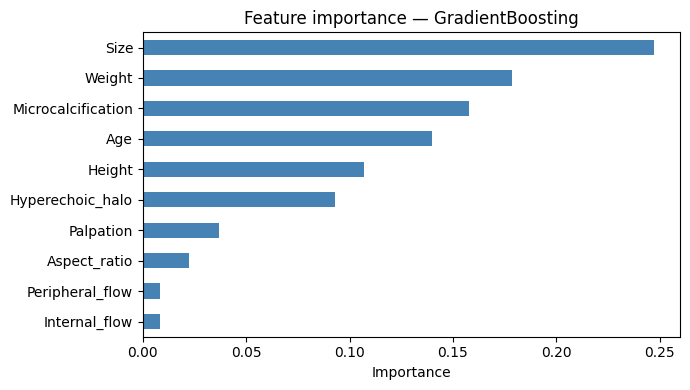

Size                  0.247508
Weight                0.178406
Microcalcification    0.157888
Age                   0.139797
Height                0.107056
Hyperechoic_halo      0.092961
Palpation             0.037029
Aspect_ratio          0.022449
Peripheral_flow       0.008519
Internal_flow         0.008387


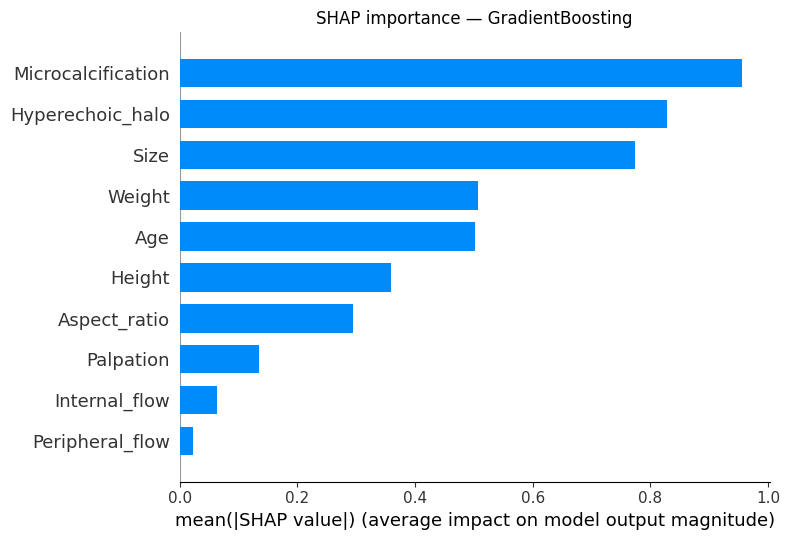

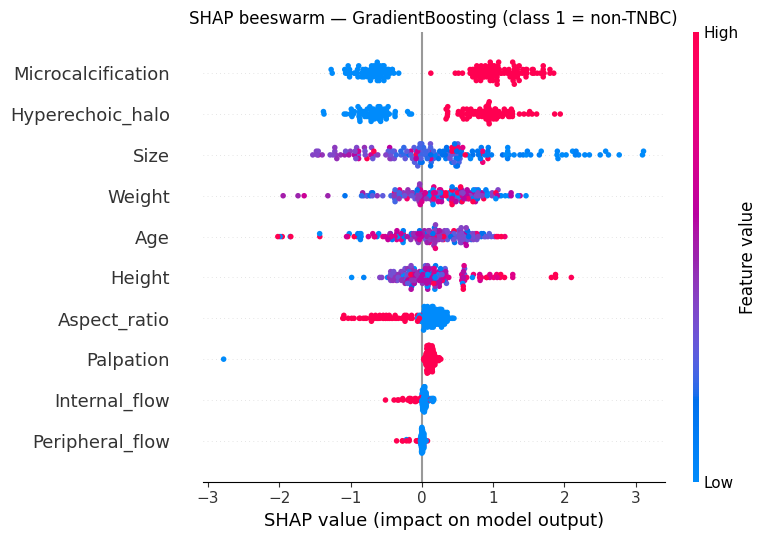

In [29]:
# ═══ Feature importance and SHAP ═════════════════════════════════════════════
import shap
TREE = ("RandomForest","XGBoost","CatBoost","GradientBoosting","AdaBoost")
is_tree = BEST_MODEL_NAME in TREE

print(f"Model: {BEST_MODEL_NAME} on {BEST_FS} features ({len(BEST_FEATURES)})")
print("SHAP for class 1 = non-TNBC. Positive -> non-TNBC, negative -> TNBC.\n")

if is_tree and hasattr(BEST_MODEL, "feature_importances_"):
    imp = pd.Series(BEST_MODEL.feature_importances_,
                    index=BEST_FEATURES).sort_values(ascending=False)
    plt.figure(figsize=(7,4)); imp.plot.barh(color="steelblue")
    plt.gca().invert_yaxis(); plt.xlabel("Importance")
    plt.title(f"Feature importance — {BEST_MODEL_NAME}")
    plt.tight_layout(); plt.show()
    print(imp.to_string())

if is_tree:
    expl = shap.TreeExplainer(BEST_MODEL); sv = expl.shap_values(X_best_te)
    if isinstance(sv, list): sv = sv[1]
    if hasattr(sv,"ndim") and sv.ndim == 3: sv = sv[:,:,1]
    Xs = X_best_te
else:
    bg = shap.sample(Xsm_best, 100, random_state=RANDOM_STATE)
    expl = shap.KernelExplainer(
        lambda z: BEST_MODEL.predict_proba(pd.DataFrame(z, columns=BEST_FEATURES))[:,1], bg)
    Xs = X_best_te.iloc[:100]; sv = expl.shap_values(Xs, nsamples=100)

shap.summary_plot(sv, Xs, plot_type="bar", show=False)
plt.title(f"SHAP importance — {BEST_MODEL_NAME}"); plt.tight_layout(); plt.show()
shap.summary_plot(sv, Xs, show=False)
plt.title(f"SHAP beeswarm — {BEST_MODEL_NAME} (class 1 = non-TNBC)")
plt.tight_layout(); plt.show()

LIME — instance 0 — class 1 (non-TNBC):
   Microcalcification <= 0.00: -0.2970
   Hyperechoic_halo <= 0.00: -0.2344
   Height > 160.00: +0.1537
   0.00 < Aspect_ratio <= 1.00: -0.0808
   Size > 3.60: -0.0800
   Age <= 43.00: -0.0659
   58.00 < Weight <= 65.00: -0.0577
   Internal_flow > 0.00: -0.0254
   Peripheral_flow <= 0.00: -0.0146
   Palpation <= 1.00: +0.0000


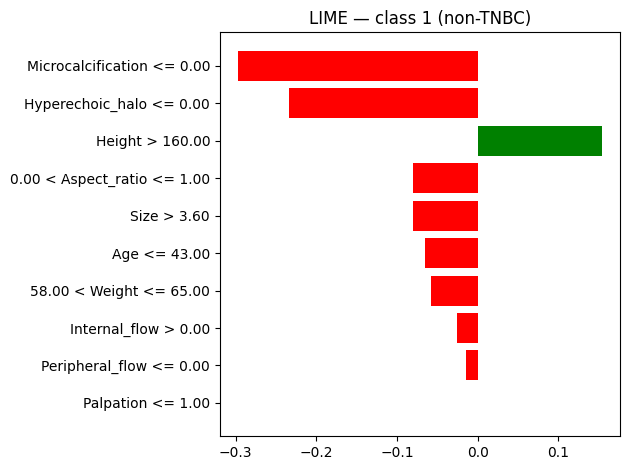

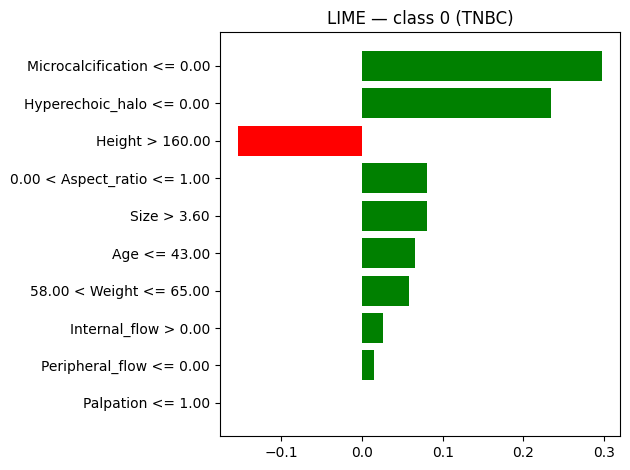

In [30]:
# ═══ LIME ════════════════════════════════════════════════════════════════════
from lime.lime_tabular import LimeTabularExplainer
lime_exp = LimeTabularExplainer(training_data=Xsm_best.values,
    feature_names=BEST_FEATURES, class_names=["TNBC (0)","non-TNBC (1)"],
    mode="classification", discretize_continuous=True, random_state=RANDOM_STATE)

e = lime_exp.explain_instance(X_best_te.values[0], BEST_MODEL.predict_proba,
        num_features=min(12,len(BEST_FEATURES)), labels=(0,1))
print("LIME — instance 0 — class 1 (non-TNBC):")
for f,w in e.as_list(label=1): print(f"   {f}: {w:+.4f}")
e.as_pyplot_figure(label=1); plt.title(f"LIME — class 1 (non-TNBC)")
plt.tight_layout(); plt.show()
e.as_pyplot_figure(label=0); plt.title(f"LIME — class 0 (TNBC)")
plt.tight_layout(); plt.show()

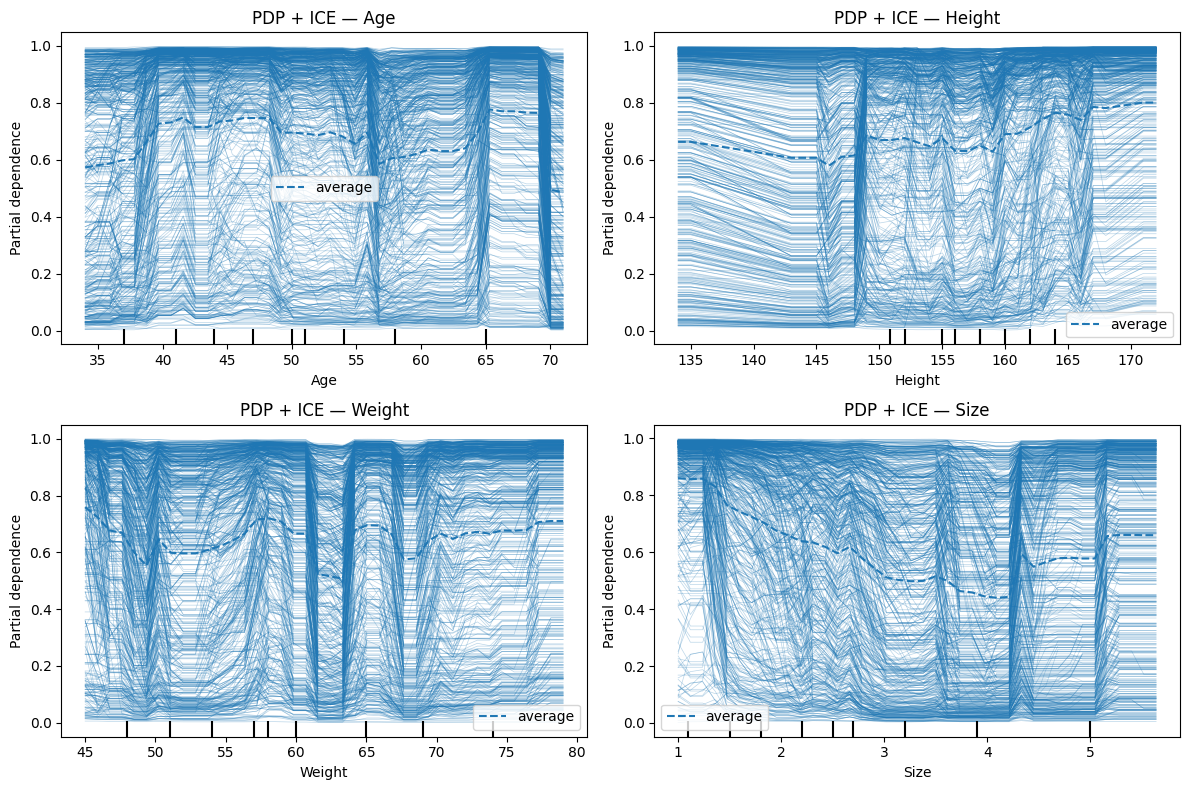

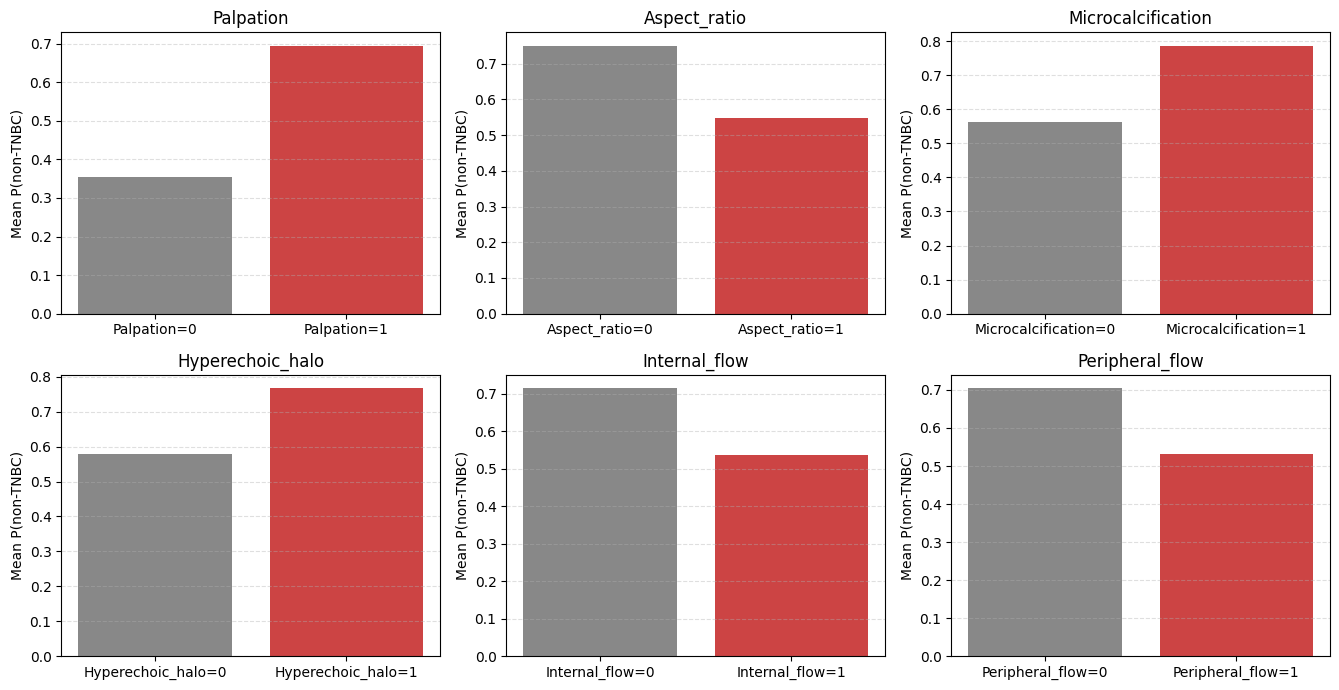

In [31]:
# ═══ PDP + ICE ═══════════════════════════════════════════════════════════════
# Computed on the ORIGINAL training data, not the SMOTE-resampled set —
# synthetic minority points distort the marginal distribution PDP averages over.
# PDP estimates can also mislead under correlated predictors (comment 7).
from sklearn.inspection import PartialDependenceDisplay

X_pdp = X_train[BEST_FEATURES]
cont = [f for f in BEST_FEATURES if X_pdp[f].nunique() > 2]
binr = [f for f in BEST_FEATURES if X_pdp[f].nunique() <= 2]

if cont:
    nc = min(2,len(cont)); nr = int(np.ceil(len(cont)/nc))
    fig, ax = plt.subplots(nr, nc, figsize=(6*nc, 4*nr)); ax = np.atleast_1d(ax).ravel()
    for a, f in zip(ax, cont):
        PartialDependenceDisplay.from_estimator(BEST_MODEL, X_pdp, [f],
            kind="both", grid_resolution=40, response_method="predict_proba", ax=a)
        a.set_title(f"PDP + ICE — {f}"); a.set_ylabel("P(non-TNBC)")
    for a in ax[len(cont):]: a.axis("off")
    plt.tight_layout(); plt.show()

if binr:
    proba = BEST_MODEL.predict_proba(X_pdp)[:,1]
    nc = min(3,len(binr)); nr = int(np.ceil(len(binr)/nc))
    fig, ax = plt.subplots(nr, nc, figsize=(4.5*nc, 3.5*nr)); ax = np.atleast_1d(ax).ravel()
    for a, f in zip(ax, binr):
        mn = pd.DataFrame({f:X_pdp[f].values,"p":proba}).groupby(f)["p"].mean()
        a.bar([f"{f}=0",f"{f}=1"],[mn.get(0,np.nan),mn.get(1,np.nan)],
              color=["#888","#c44"])
        a.set_ylabel("Mean P(non-TNBC)"); a.set_title(f)
        a.grid(axis="y", ls="--", alpha=.4)
    for a in ax[len(binr):]: a.axis("off")
    plt.tight_layout(); plt.show()

In [32]:
# ═══ DiCE counterfactuals ════════════════════════════════════════════════════
# Binary features are declared categorical so DiCE cannot emit impossible
# values such as Microcalcification = 0.63 (comment 7).
import dice_ml
from dice_ml import Dice

TARGET = "cancer"
cont_f = [f for f in BEST_FEATURES if X_train[f].nunique() > 2]
cat_f  = [f for f in BEST_FEATURES if X_train[f].nunique() <= 2]

class NumericCoercer:
    def __init__(s, m, cols):
        s.m, s.cols = m, list(cols)
        s.classes_ = getattr(m, "classes_", np.array([0,1]))
    def _p(s, Z):
        Z = pd.DataFrame(Z, columns=s.cols) if not isinstance(Z, pd.DataFrame) else Z.copy()
        for c in s.cols: Z[c] = pd.to_numeric(Z[c], errors="coerce").astype(float)
        return Z[s.cols]
    def predict(s, Z):       return s.m.predict(s._p(Z))
    def predict_proba(s, Z): return s.m.predict_proba(s._p(Z))

dfd = Xsm_best.copy(); dfd[TARGET] = np.asarray(ysm_best)
for f in cat_f: dfd[f] = dfd[f].round().astype(int)
d = dice_ml.Data(dataframe=dfd, continuous_features=cont_f, outcome_name=TARGET)
m = dice_ml.Model(model=NumericCoercer(BEST_MODEL, BEST_FEATURES), backend="sklearn")
q = X_best_te.iloc[[0]].copy()
for f in cat_f: q[f] = q[f].round().astype(int)
cf = Dice(d, m, method="random").generate_counterfactuals(
        q, total_CFs=3, desired_class="opposite")

print("DiCE counterfactuals, test instance 0.")
print("A flip of the outcome column means RECLASSIFICATION between subtypes")
print("(1 = non-TNBC -> 0 = TNBC), NOT resolution of disease.")
print("Lesion size, microcalcification and vascular flow are diagnostic")
print("observations, not interventions — these are not actionable changes.")
cf.visualize_as_dataframe()

100%|██████████| 1/1 [00:00<00:00,  8.15it/s]

DiCE counterfactuals, test instance 0.
A flip of the outcome column means RECLASSIFICATION between subtypes
(1 = non-TNBC -> 0 = TNBC), NOT resolution of disease.
Lesion size, microcalcification and vascular flow are diagnostic
observations, not interventions — these are not actionable changes.
Query instance (original outcome : 0)


,Age,Height,Weight,Size,Palpation,Aspect_ratio,Microcalcification,Hyperechoic_halo,Internal_flow,Peripheral_flow,cancer
0,38,168,63.0,6.8,1,1,0,0,1,0,0



Diverse Counterfactual set (new outcome: 1)


,Age,Height,Weight,Size,Palpation,Aspect_ratio,Microcalcification,Hyperechoic_halo,Internal_flow,Peripheral_flow,cancer
0,38,137,40.8,6.8,1,1,0,0,1,0,1
1,38,168,87.5,6.8,1,1,0,0,1,0,1
2,38,168,63.0,6.8,0,1,1,0,1,0,1


---
# 8. Calibration and clinical utility

Referee 2, comment 8: a Brier score alone does not establish calibration.
Reported here are the calibration slope and intercept with bootstrap CIs, an
internally validated calibration curve, and decision curve analysis.

**Decision curve framing.** The event of interest is **TNBC**, since flagging
a likely TNBC case to prioritise confirmatory immunohistochemistry is the
decision where subtype information changes management.

In [33]:
from sklearn.calibration import calibration_curve
from sklearn.tree import DecisionTreeClassifier, _tree
from scipy.optimize import minimize
from scipy.special import logit

def calibration_stats(yt, p, n_boot=1000, seed=RANDOM_STATE):
    p = np.clip(np.asarray(p,float), 1e-6, 1-1e-6); yv = np.asarray(yt,float)
    lp = logit(p)
    def fit(y_, l_):
        nll  = lambda par: -np.sum(y_*(par[0]+par[1]*l_) - np.log1p(np.exp(par[0]+par[1]*l_)))
        b = minimize(nll,[0.,1.],method="BFGS").x[1]
        nll0 = lambda a: -np.sum(y_*(a+l_) - np.log1p(np.exp(a+l_)))
        return float(b), float(minimize(nll0,[0.],method="BFGS").x[0])
    slope, citl = fit(yv, lp)
    rng, bs, bc = np.random.RandomState(seed), [], []
    for _ in range(n_boot):
        i = rng.randint(0,len(yv),len(yv))
        if len(np.unique(yv[i])) < 2: continue
        s_, c_ = fit(yv[i], lp[i]); bs.append(s_); bc.append(c_)
    return slope, (np.percentile(bs,2.5),np.percentile(bs,97.5)), \
           citl,  (np.percentile(bc,2.5),np.percentile(bc,97.5))

# Build the target list defensively. `models` may contain transformer entries
# added in §6, some stored as dicts rather than estimators.
_pool = ML_MODELS if "ML_MODELS" in dir() else models
cal_targets = {}
for name, obj in _pool.items():
    mdl = obj.get("model") if isinstance(obj, dict) else obj
    if mdl is not None and hasattr(mdl, "predict_proba"):
        cal_targets[name] = mdl
cal_targets[f"SELECTED_{BEST_MODEL_NAME}"] = BEST_MODEL

print("Calibration (ideal: slope 1.0, intercept 0.0)\n")
cal_rows = []
for name, mdl in cal_targets.items():
    feats = BEST_FEATURES if name.startswith("SELECTED") else selected_features
    try:
        ps = mdl.predict_proba(X_test[feats])[:,1]
    except Exception as e:
        print(f"  skip {name:26s} ({type(e).__name__})")
        continue
    sl, slci, ic, icci = calibration_stats(y_test, ps)
    flag = "" if slci[0] <= 1.0 <= slci[1] else "  <- CI excludes 1.0"
    print(f"  {name:28s} slope {sl:.3f} ({slci[0]:.3f}-{slci[1]:.3f})   "
          f"intercept {ic:+.3f} ({icci[0]:+.3f} to {icci[1]:+.3f}){flag}")
    cal_rows.append({"Model":name,"slope":sl,"slope_lo":slci[0],"slope_hi":slci[1],
                     "intercept":ic,"int_lo":icci[0],"int_hi":icci[1]})

pd.DataFrame(cal_rows).to_csv("calibration_stats.csv", index=False)
print(f"\n{len(cal_rows)} models assessed. Saved: calibration_stats.csv")

Calibration (ideal: slope 1.0, intercept 0.0)

  LogisticRegression           slope 0.707 (0.286-1.188)   intercept +0.720 (+0.358 to +1.117)
  KNN                          slope 0.170 (0.123-0.257)   intercept +0.418 (-0.331 to +1.197)  <- CI excludes 1.0
  SVM                          slope 0.440 (0.182-0.763)   intercept +0.413 (-0.041 to +0.939)  <- CI excludes 1.0
  RandomForest                 slope 1.008 (0.705-1.464)   intercept +0.245 (-0.143 to +0.688)
  AdaBoost                     slope 3.058 (1.933-4.547)   intercept +0.785 (+0.479 to +1.171)  <- CI excludes 1.0
  GradientBoosting             slope 0.818 (0.629-1.129)   intercept +0.077 (-0.415 to +0.639)
  XGBoost                      slope 0.582 (0.443-0.792)   intercept -0.243 (-0.894 to +0.491)  <- CI excludes 1.0
  CatBoost                     slope 0.521 (0.396-0.739)   intercept -0.250 (-0.946 to +0.642)  <- CI excludes 1.0
  SELECTED_GradientBoosting    slope 0.818 (0.629-1.129)   intercept +0.077 (-0.415 to +0.639

DCA: model beats both defaults for thresholds 0.05-0.90


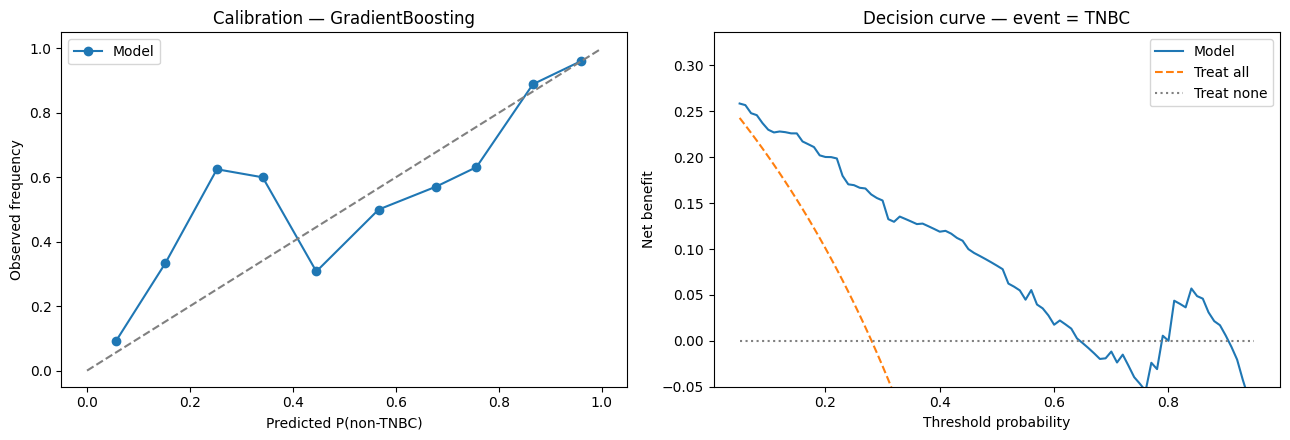

In [34]:
# ── Decision curve analysis, event = TNBC ────────────────────────────────────
ps = BEST_MODEL.predict_proba(X_best_te)[:,1]
yt = np.asarray(y_test).ravel()
p_tnbc, y_tnbc = 1-ps, (yt==0).astype(int)
n, prev = len(y_tnbc), y_tnbc.mean()

dca = pd.DataFrame([{"threshold":t,
    "model": ((p_tnbc>=t)&(y_tnbc==1)).sum()/n - ((p_tnbc>=t)&(y_tnbc==0)).sum()/n*(t/(1-t)),
    "treat_all": prev-(1-prev)*(t/(1-t)), "treat_none":0.0}
    for t in np.arange(0.05,0.96,0.01)])
dca.to_csv("decision_curve.csv", index=False)
b = dca[dca.model > dca[["treat_all","treat_none"]].max(axis=1)]
print(f"DCA: model beats both defaults for thresholds "
      f"{b.threshold.min():.2f}-{b.threshold.max():.2f}" if len(b)
      else "DCA: model never exceeds both default strategies")

fig, ax = plt.subplots(1,2, figsize=(13,4.5))
fp_, mp_ = calibration_curve(yt, ps, n_bins=10)
ax[0].plot(mp_, fp_, "o-", label="Model"); ax[0].plot([0,1],[0,1],"--",c="grey")
ax[0].set_xlabel("Predicted P(non-TNBC)"); ax[0].set_ylabel("Observed frequency")
ax[0].set_title(f"Calibration — {BEST_MODEL_NAME}"); ax[0].legend()
ax[1].plot(dca.threshold, dca.model, label="Model")
ax[1].plot(dca.threshold, dca.treat_all, "--", label="Treat all")
ax[1].plot(dca.threshold, dca.treat_none, ":", c="grey", label="Treat none")
ax[1].set_ylim(-0.05, dca.model.max()*1.3)
ax[1].set_xlabel("Threshold probability"); ax[1].set_ylabel("Net benefit")
ax[1].set_title("Decision curve — event = TNBC"); ax[1].legend()
plt.tight_layout(); plt.show()

In [35]:
# ── Anchor-like rule ────────────────────────────────────────────────────────
# Binary features are perturbed by FLIPPING, not by adding Gaussian noise,
# which previously produced impossible inputs and a degenerate rule (comment 7).
rng = np.random.RandomState(RANDOM_STATE)
cols, x0 = list(BEST_FEATURES), X_best_te.iloc[0].values.astype(float)
Z = np.tile(x0,(2000,1))
for j,c in enumerate(cols):
    if c in cat_f:
        fl = rng.rand(2000) < 0.20; Z[fl,j] = 1.0 - Z[fl,j]
    else:
        Z[:,j] += rng.normal(0,0.10,2000)*(X_train[c].std() or 1e-6)
Zdf = pd.DataFrame(Z, columns=cols)
sur = DecisionTreeClassifier(max_depth=3, min_samples_leaf=25,
        random_state=RANDOM_STATE).fit(Zdf, BEST_MODEL.predict(Zdf))
t_, node, parts = sur.tree_, 0, []
while t_.feature[node] != _tree.TREE_UNDEFINED:
    f, th = cols[t_.feature[node]], t_.threshold[node]
    if x0[t_.feature[node]] <= th: parts.append((f,"<=",th)); node = t_.children_left[node]
    else:                          parts.append((f,">",th));  node = t_.children_right[node]
mask = np.ones(len(X_best_te), bool)
for f,o,th in parts:
    mask &= (X_best_te[f].values<=th) if o=="<=" else (X_best_te[f].values>th)
ym = BEST_MODEL.predict(X_best_te); pc = int(ym[0])
prec = (ym[mask]==pc).mean() if mask.sum() else 0.0
base = max((yt==0).mean(), (yt==1).mean())
print(f"Anchor rule for class {pc} ({CLASS_NAMES[pc]}):")
print("  " + "  AND  ".join(f"{f} {o} {th:.3f}" for f,o,th in parts))
print(f"  Precision {prec:.4f} | Coverage {mask.mean():.4f} | Baseline {base:.4f}")
if prec <= base + 0.05:
    print("  NOT discriminative — precision is near the majority baseline.")
    print("  Report as a negative finding, not a clinically useful rule.")

Anchor rule for class 0 (TNBC):
  Microcalcification <= 0.500  AND  Hyperechoic_halo <= 0.500  AND  Aspect_ratio > 0.500
  Precision 0.7500 | Coverage 0.0702 | Baseline 0.7193
  NOT discriminative — precision is near the majority baseline.
  Report as a negative finding, not a clinically useful rule.


---
# 9. Summary

In [36]:
print("="*76); print("SUMMARY FOR THE MANUSCRIPT"); print("="*76)
print(f"\nCohort  : {len(df)} patients, {(y==0).sum()} TNBC / {(y==1).sum()} non-TNBC")
print(f"Test set: {(y_test==0).sum()} TNBC / {(y_test==1).sum()} non-TNBC")
print(f"No-information rate: {nir:.4f}")

print(f"\nFeature selection")
print(f"  RCCO   ({len(selected_features)}): {sorted(selected_features)}")
print(f"  Boruta ({len(boruta_features)}): {sorted(boruta_features)}")
print("\n  RCCO vs Boruta, nested CV, pooled across models:")
for m_ in CORE:
    mu, sig = fs_verdict[m_]
    print(f"    {m_:14s} {mu:+.4f}{'   SIGNIFICANT' if sig else ''}")

print(f"\nSelected model: {BEST_FS} + {BEST_MODEL_NAME} (prespecified rule)")
print(f"XAI applied to: {BEST_MODEL_NAME}")

print("""
REFEREE COMMENTS ADDRESSED IN THIS NOTEBOOK

  R2-2  descriptive statistics, provenance, missing-data count      §2
  R2-3  repeated nested CV, no test-set leakage                     §5b
  R2-4  confusion matrices, PPV/NPV/MCC, bootstrap CIs, NIR         §5a
  R2-5  RCCO vs Boruta in an identical nested scheme                §3, §5b
  R2-6  identical tuning budget for all models; RF search           §4, §4b
        strategies reported as strategies, not as separate models
  R2-7  XAI reframed as model behaviour; DiCE categoricals fixed;   §7
        anchor rule tested against the majority baseline
  R2-8  calibration slope and intercept with CIs; decision curves   §8
  R2-11 encoding: all predictors continuous or already binary       §2
  R2-12 scaling fitted per fold inside Pipelines                    §2
  R2-13 SMOTE on training folds only, exact ratios reported         §4

  STILL REQUIRED OUTSIDE THIS NOTEBOOK
    R1-1  workflow figure
    R1-2  public GitHub repository
    R1-3  consolidate to 5 figures and 5 tables
    R2-5  clinically prespecified feature set (needs radiological input)
    R2-16 TRIPOD+AI checklist and PROBAST+AI assessment
""")
import sklearn, xgboost, catboost, imblearn, scipy
print(f"Versions: scikit-learn {sklearn.__version__}, xgboost {xgboost.__version__}, "
      f"catboost {catboost.__version__}, imbalanced-learn {imblearn.__version__}, "
      f"numpy {np.__version__}, scipy {scipy.__version__}")

SUMMARY FOR THE MANUSCRIPT

Cohort  : 855 patients, 241 TNBC / 614 non-TNBC
Test set: 48 TNBC / 123 non-TNBC
No-information rate: 0.7193

Feature selection
  RCCO   (10): ['Age', 'Aspect_ratio', 'Height', 'Hyperechoic_halo', 'Internal_flow', 'Microcalcification', 'Palpation', 'Peripheral_flow', 'Size', 'Weight']
  Boruta (5): ['Age', 'Architectural_distortion', 'Aspect_ratio', 'Microcalcification', 'Size']

  RCCO vs Boruta, nested CV, pooled across models:
    Accuracy       +0.0543   SIGNIFICANT
    Recall         +0.0608   SIGNIFICANT
    Specificity    +0.0377   SIGNIFICANT
    F1             +0.0445   SIGNIFICANT
    ROC_AUC        +0.0547   SIGNIFICANT
    MCC            +0.1035   SIGNIFICANT
    BalancedAcc    +0.0492   SIGNIFICANT

Selected model: RCCO + GradientBoosting (prespecified rule)
XAI applied to: GradientBoosting

REFEREE COMMENTS ADDRESSED IN THIS NOTEBOOK

  R2-2  descriptive statistics, provenance, missing-data count      §2
  R2-3  repeated nested CV, no test-set 

In [37]:
# ── Reporting: Brier score and library versions ──────────────────────────────
from sklearn.metrics import brier_score_loss

_ps = BEST_MODEL.predict_proba(X_test[BEST_FEATURES])[:, 1]
_brier = brier_score_loss(y_test, _ps)
print(f"Brier score ({BEST_MODEL_NAME}): {_brier:.4f}\n")

print("Library versions")
import importlib
for _lib, _label in [("sklearn", "scikit-learn"), ("xgboost", "XGBoost"),
                     ("catboost", "CatBoost"), ("imblearn", "imbalanced-learn"),
                     ("numpy", "NumPy"), ("pandas", "pandas"),
                     ("scipy", "SciPy"), ("torch", "PyTorch"),
                     ("tabpfn_client", "tabpfn-client")]:
    try:
        print(f"  {_label:18s} {importlib.import_module(_lib).__version__}")
    except Exception as _e:
        print(f"  {_label:18s} unavailable ({type(_e).__name__})")

Brier score (GradientBoosting): 0.1358

Library versions
  scikit-learn       1.6.1
  XGBoost            3.4.1
  CatBoost           1.2.10
  imbalanced-learn   0.14.2
  NumPy              2.1.3
  pandas             2.2.3
  SciPy              1.16.3
  PyTorch            2.11.0+cu128
  tabpfn-client      unavailable (ModuleNotFoundError)
